In [1]:
from pathlib import Path
import pandas as pd

print("Dossier courant :", Path.cwd())

data_path = Path("../data/raw/2016_Building_Energy_Benchmarking.csv")
hist_path = Path("../data/raw/Building_Energy_Benchmarking_Data,_2015-Present_20260330.csv")

print("Data path exists :", data_path.exists(), data_path)
print("Hist path exists :", hist_path.exists(), hist_path)

building_consumption = pd.read_csv(data_path, low_memory=False)
df_hist = pd.read_csv(hist_path, low_memory=False)

print("Dimensions 2016 :", building_consumption.shape)
print("Dimensions historique :", df_hist.shape)

Dossier courant : /Users/vincentdesmouceaux/PycharmProjects/PythonProject3/notebooks
Data path exists : True ../data/raw/2016_Building_Energy_Benchmarking.csv
Hist path exists : True ../data/raw/Building_Energy_Benchmarking_Data,_2015-Present_20260330.csv
Dimensions 2016 : (3376, 46)
Dimensions historique : (34699, 46)


In [2]:
print(Path.cwd())

/Users/vincentdesmouceaux/PycharmProjects/PythonProject3/notebooks


# Analyse Exploratoire

### Import des modules

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

### Analyse Exploratoire

In [4]:
print("Dimensions :", building_consumption.shape)
building_consumption.head()

Dimensions : (3376, 46)


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


### Structure générale du jeu de données

In [5]:
building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

In [6]:
for col in building_consumption.columns:
    print(col)

OSEBuildingID
DataYear
BuildingType
PrimaryPropertyType
PropertyName
Address
City
State
ZipCode
TaxParcelIdentificationNumber
CouncilDistrictCode
Neighborhood
Latitude
Longitude
YearBuilt
NumberofBuildings
NumberofFloors
PropertyGFATotal
PropertyGFAParking
PropertyGFABuilding(s)
ListOfAllPropertyUseTypes
LargestPropertyUseType
LargestPropertyUseTypeGFA
SecondLargestPropertyUseType
SecondLargestPropertyUseTypeGFA
ThirdLargestPropertyUseType
ThirdLargestPropertyUseTypeGFA
YearsENERGYSTARCertified
ENERGYSTARScore
SiteEUI(kBtu/sf)
SiteEUIWN(kBtu/sf)
SourceEUI(kBtu/sf)
SourceEUIWN(kBtu/sf)
SiteEnergyUse(kBtu)
SiteEnergyUseWN(kBtu)
SteamUse(kBtu)
Electricity(kWh)
Electricity(kBtu)
NaturalGas(therms)
NaturalGas(kBtu)
DefaultData
Comments
ComplianceStatus
Outlier
TotalGHGEmissions
GHGEmissionsIntensity


In [7]:
for col in ["BuildingType", "PrimaryPropertyType", "Neighborhood"]:
    if col in building_consumption.columns:
        print(f"\n--- {col} ---")
        print(building_consumption[col].value_counts(dropna=False).head(20).to_string())


--- BuildingType ---
BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1

--- PrimaryPropertyType ---
PrimaryPropertyType
Low-Rise Multifamily           987
Mid-Rise Multifamily           564
Small- and Mid-Sized Office    293
Other                          256
Warehouse                      187
Large Office                   173
K-12 School                    139
Mixed Use Property             133
High-Rise Multifamily          105
Retail Store                    91
Hotel                           77
Worship Facility                71
Distribution Center             53
Senior Care Community           45
Supermarket / Grocery Store     40
Medical Office                  39
Self-Storage Facility           28
University                      25
Residence Hall                  23
Refrigerated Wareho

### Valeurs manquantes

In [8]:
missing = (
    building_consumption.isna()
    .sum()
    .to_frame("nb_manquants")
    .assign(pct_manquants=lambda x: 100 * x["nb_manquants"] / len(building_consumption))
    .sort_values("pct_manquants", ascending=False)
)

missing.head(30)

,nb_manquants,pct_manquants
Comments,3376,100.000000
Outlier,3344,99.052133
YearsENERGYSTARCertified,3257,96.475118
ThirdLargestPropertyUseType,2780,82.345972
ThirdLargestPropertyUseTypeGFA,2780,82.345972
SecondLargestPropertyUseType,1697,50.266588
SecondLargestPropertyUseTypeGFA,1697,50.266588
ENERGYSTARScore,843,24.970379
LargestPropertyUseTypeGFA,20,0.592417
LargestPropertyUseType,20,0.592417


### Suivi du nombre de lignes

In [9]:
suivi_lignes = []


def log_shape(df, etape):
    suivi_lignes.append({
        "etape": etape,
        "nb_lignes": df.shape[0],
        "nb_colonnes": df.shape[1]
    })


log_shape(building_consumption, "Chargement initial")

### Nettoyage métier : conservation des bâtiments non résidentiels

In [10]:
df = building_consumption.copy()

building_types_to_keep = [
    "NonResidential",
    "Nonresidential COS",
    "Nonresidential WA",
    "Campus",
    "SPS-District K-12"
]

df = df[df["BuildingType"].isin(building_types_to_keep)].copy()
log_shape(df, "Après filtrage des BuildingType non résidentiels")

df = df[df["ComplianceStatus"] == "Compliant"].copy()
log_shape(df, "Après filtre ComplianceStatus = Compliant")

df = df[~df["DefaultData"]].copy()
log_shape(df, "Après filtre DefaultData = False")

df = df[df["Outlier"].isna()].copy()
log_shape(df, "Après suppression des outliers signalés")

df.shape

(1548, 46)

### Harmonisation et suppression de colonnes peu utiles

In [11]:
df["Neighborhood"] = df["Neighborhood"].str.upper().str.strip()

cols_to_drop_now = [
    "Comments",
    "YearsENERGYSTARCertified",
    "ThirdLargestPropertyUseType",
    "ThirdLargestPropertyUseTypeGFA"
]

cols_to_drop_now = [col for col in cols_to_drop_now if col in df.columns]
df = df.drop(columns=cols_to_drop_now)

log_shape(df, "Après suppression des colonnes trop incomplètes")

df.shape

(1548, 42)

### Création d'une variable mono-usage / multi-usages

In [12]:
if "SecondLargestPropertyUseType" in df.columns:
    df["UsageType"] = df["SecondLargestPropertyUseType"].apply(
        lambda x: "Mono-usage" if pd.isna(x) else "Multi-usages"
    )

df["UsageType"].value_counts()

UsageType
Multi-usages    842
Mono-usage      706
Name: count, dtype: int64

### Choix de la cible

In [13]:
target = "SiteEnergyUse(kBtu)"

df = df[df[target].notna()].copy()
df = df[df[target] > 0].copy()
df = df[df["PropertyGFATotal"] > 0].copy()

log_shape(df, "Après suppression des lignes sans target ou surface exploitable")

df[target].describe()

count    1.548000e+03
mean     8.860058e+06
std      3.130568e+07
min      5.713320e+04
25%      1.251083e+06
50%      2.732167e+06
75%      7.294487e+06
max      8.739237e+08
Name: SiteEnergyUse(kBtu), dtype: float64

### Tableau de suivi des filtrages

In [14]:
pd.DataFrame(suivi_lignes)

,etape,nb_lignes,nb_colonnes
0,Chargement initial,3376,46
1,Après filtrage des BuildingType non résidentiels,1668,46
2,Après filtre ComplianceStatus = Compliant,1548,46
3,Après filtre DefaultData = False,1548,46
4,Après suppression des outliers signalés,1548,46
5,Après suppression des colonnes trop incomplètes,1548,42
6,Après suppression des lignes sans target ou su...,1548,43


### Statistiques descriptives

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
OSEBuildingID,1548.0,1.649794e+04,1.382788e+04,1.00000,6.027500e+02,2.118050e+04,2.460900e+04,5.022600e+04
DataYear,1548.0,2.016000e+03,0.000000e+00,2016.00000,2.016000e+03,2.016000e+03,2.016000e+03,2.016000e+03
ZipCode,1535.0,9.811678e+04,1.869557e+01,98006.00000,9.810400e+04,9.810900e+04,9.812500e+04,9.819900e+04
CouncilDistrictCode,1548.0,4.415375e+00,2.191527e+00,1.00000,2.000000e+00,4.000000e+00,7.000000e+00,7.000000e+00
Latitude,1548.0,4.761649e+01,4.695384e-02,47.50959,4.758786e+01,4.761271e+01,4.764906e+01,4.773387e+01
Longitude,1548.0,-1.223335e+02,2.326372e-02,-122.41182,-1.223430e+02,-1.223332e+02,-1.223227e+02,-1.222618e+02
YearBuilt,1548.0,1.961644e+03,3.288692e+01,1900.00000,1.930000e+03,1.965500e+03,1.989000e+03,2.015000e+03
NumberofBuildings,1548.0,1.178941e+00,3.039221e+00,0.00000,1.000000e+00,1.000000e+00,1.000000e+00,1.110000e+02
NumberofFloors,1548.0,4.276486e+00,6.780694e+00,0.00000,1.000000e+00,2.000000e+00,4.000000e+00,9.900000e+01
PropertyGFATotal,1548.0,1.213321e+05,3.062944e+05,11285.00000,2.884325e+04,4.815900e+04,1.076615e+05,9.320156e+06


### Distribution de la cible

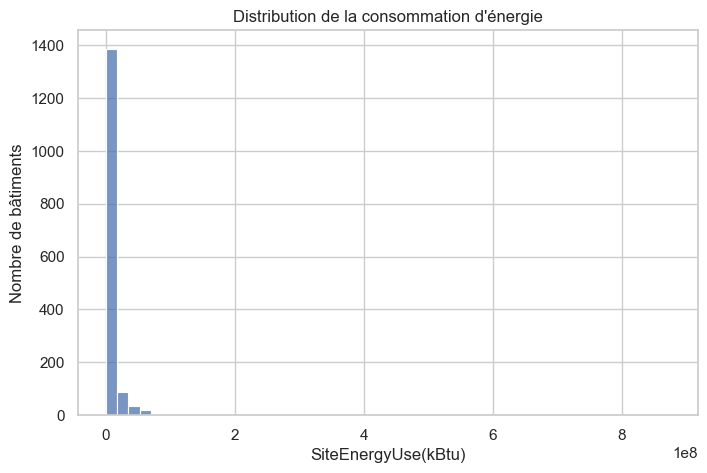

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df[target], bins=50)
plt.title("Distribution de la consommation d'énergie")
plt.xlabel(target)
plt.ylabel("Nombre de bâtiments")
plt.show()

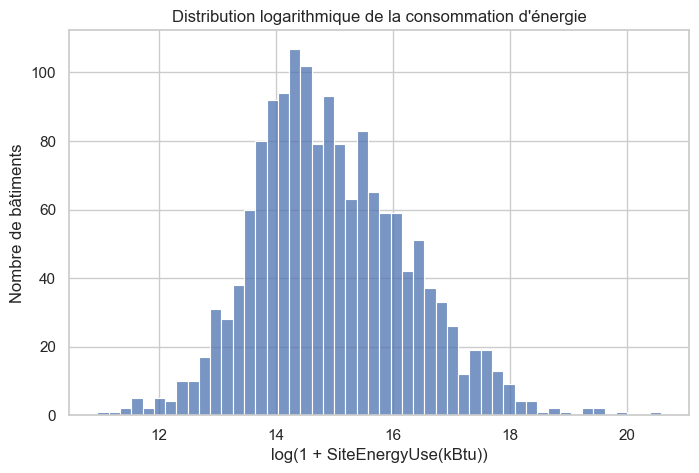

In [17]:
df_plot = df.copy()
df_plot["target_log"] = np.log1p(df_plot[target])

plt.figure(figsize=(8, 5))
sns.histplot(df_plot["target_log"], bins=50)
plt.title("Distribution logarithmique de la consommation d'énergie")
plt.xlabel(f"log(1 + {target})")
plt.ylabel("Nombre de bâtiments")
plt.show()

### Surface totale vs consommation

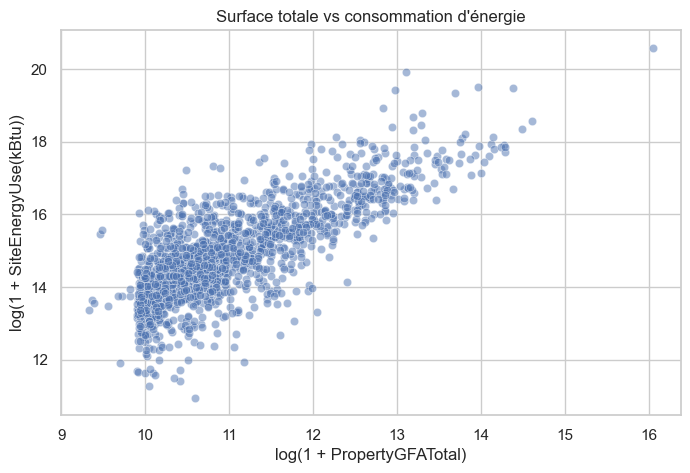

In [18]:
temp = df[(df["PropertyGFATotal"] > 0) & (df[target] > 0)].copy()
temp["log_gfa"] = np.log1p(temp["PropertyGFATotal"])
temp["target_log"] = np.log1p(temp[target])

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=temp,
    x="log_gfa",
    y="target_log",
    alpha=0.5
)
plt.title("Surface totale vs consommation d'énergie")
plt.xlabel("log(1 + PropertyGFATotal)")
plt.ylabel(f"log(1 + {target})")
plt.show()

### Consommation par type principal de bâtiment

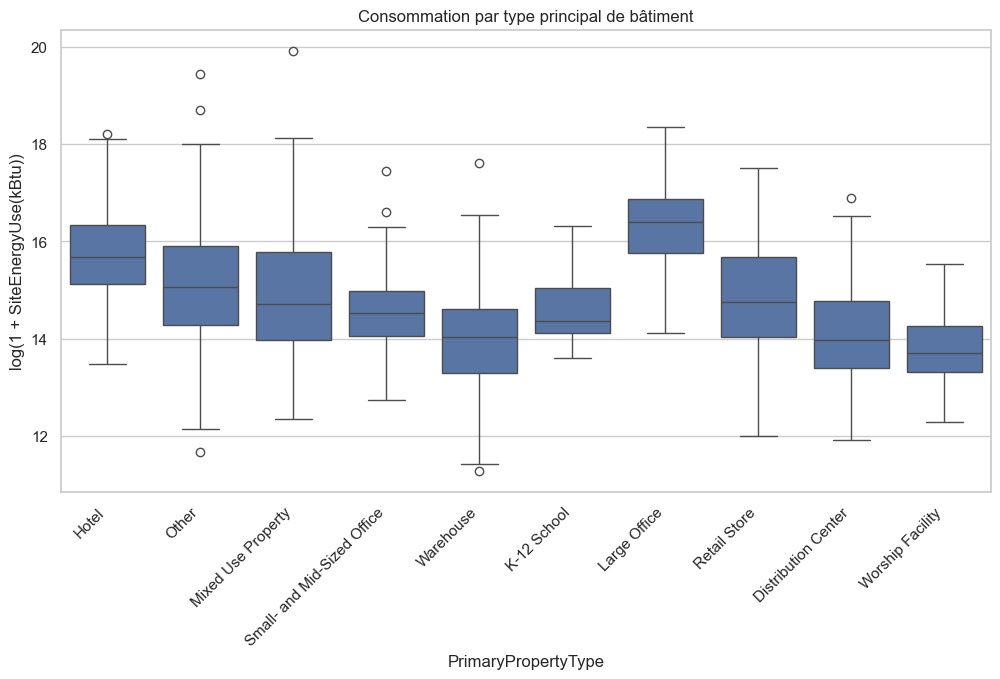

In [19]:
top_types = df["PrimaryPropertyType"].value_counts().head(10).index
temp = df[df["PrimaryPropertyType"].isin(top_types)].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=temp,
    x="PrimaryPropertyType",
    y=np.log1p(temp[target])
)
plt.xticks(rotation=45, ha="right")
plt.title("Consommation par type principal de bâtiment")
plt.ylabel(f"log(1 + {target})")
plt.show()

### Mono-usage vs multi-usages

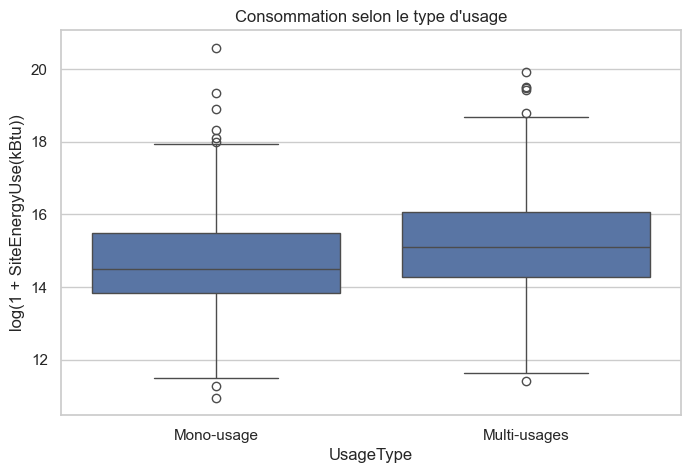

In [20]:
df_plot = df.copy()
df_plot["target_log"] = np.log1p(df_plot[target])

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_plot,
    x="UsageType",
    y="target_log"
)
plt.title("Consommation selon le type d'usage")
plt.ylabel(f"log(1 + {target})")
plt.show()

### Corrélations entre variables numériques

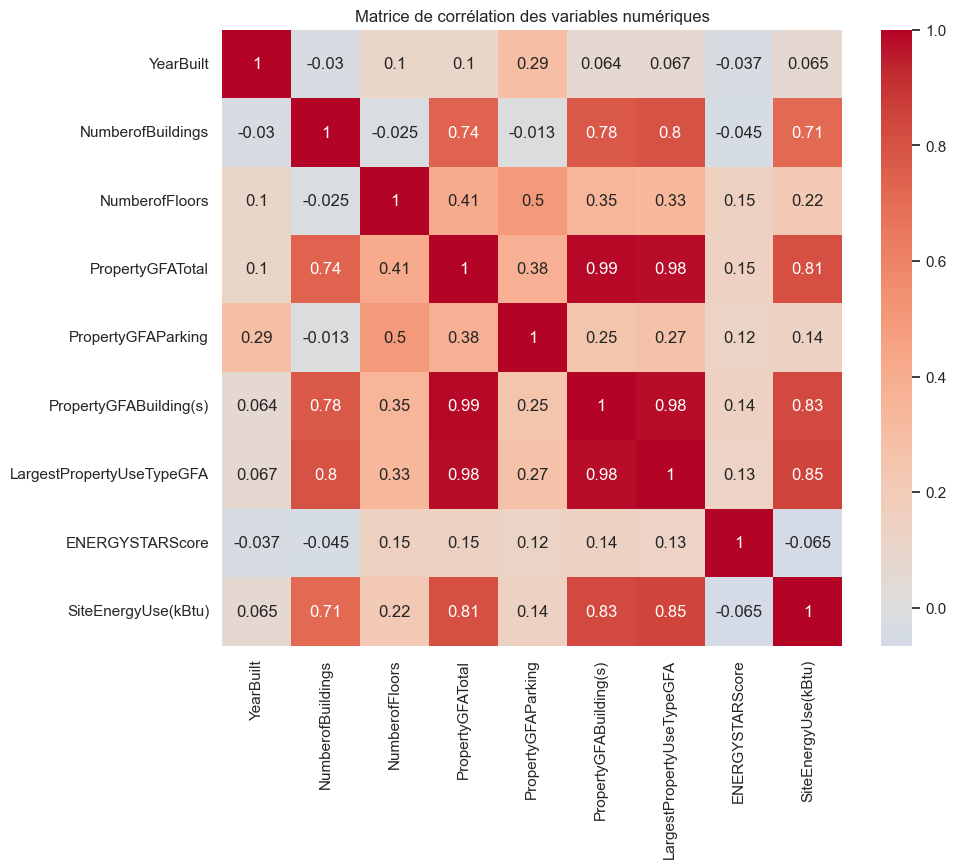

In [21]:
cols_corr = [
    "YearBuilt",
    "NumberofBuildings",
    "NumberofFloors",
    "PropertyGFATotal",
    "PropertyGFAParking",
    "PropertyGFABuilding(s)",
    "LargestPropertyUseTypeGFA",
    "ENERGYSTARScore",
    target
]

cols_corr = [col for col in cols_corr if col in df.columns]

corr = df[cols_corr].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation des variables numériques")
plt.show()

#### TERMINER L'ANALYSE EXPLORATOIRE

### 1. Colonnes conservées et logique métier

Les colonnes conservées à ce stade peuvent être regroupées en plusieurs familles :

- **Colonnes d’identification et de localisation** : `OSEBuildingID`, `Neighborhood`, `Latitude`, `Longitude`, `ZipCode`.
- **Colonnes décrivant la structure du bâtiment** : `YearBuilt`, `NumberofBuildings`, `NumberofFloors`, `PropertyGFATotal`, `PropertyGFAParking`, `PropertyGFABuilding(s)`.
- **Colonnes décrivant l’usage du bâtiment** : `BuildingType`, `PrimaryPropertyType`, `LargestPropertyUseType`, `SecondLargestPropertyUseType`, `LargestPropertyUseTypeGFA`.
- **Colonnes énergétiques et environnementales** : `SiteEnergyUse(kBtu)`, `SiteEnergyUseWN(kBtu)`, `ENERGYSTARScore`, `TotalGHGEmissions`, `GHGEmissionsIntensity`.

Ces variables permettent de décrire les bâtiments selon leur **taille**, leur **fonction**, leur **implantation** et leur **performance énergétique**, ce qui est cohérent avec l’objectif de prédiction de la consommation.

### 2. Colonnes supprimées et justification

Certaines colonnes ont été supprimées dès l’analyse exploratoire :

- `Comments` a été supprimée car elle est entièrement vide.
- `YearsENERGYSTARCertified` a été retirée car elle contient une très forte proportion de valeurs manquantes.
- `ThirdLargestPropertyUseType` et `ThirdLargestPropertyUseTypeGFA` ont également été retirées car elles sont trop peu renseignées pour être exploitées de façon robuste.

Par ailleurs, plusieurs lignes ont été exclues pour respecter le périmètre métier du projet :
- les bâtiments résidentiels de type `Multifamily` ont été retirés ;
- seules les lignes **Compliant** ont été conservées ;
- les lignes avec une cible manquante ou non exploitable ont été supprimées ;
- seules les observations décrivant des bâtiments non résidentiels ont été conservées.

Enfin, la colonne `Neighborhood` a été harmonisée en majuscules afin de corriger les doublons de casse comme `North` / `NORTH` ou `Ballard` / `BALLARD`.

### 3. Colonnes constantes ou peu informatives

In [22]:
constant_cols = []
quasi_constant_cols = []

for col in df.columns:
    freq = df[col].value_counts(dropna=False, normalize=True)
    if len(freq) == 1:
        constant_cols.append(col)
    elif len(freq) > 0 and freq.iloc[0] > 0.95:
        quasi_constant_cols.append(col)

print("Colonnes constantes :", constant_cols)
print("Colonnes quasi constantes (>95 % même valeur) :", quasi_constant_cols)

Colonnes constantes : ['DataYear', 'City', 'State', 'DefaultData', 'ComplianceStatus', 'Outlier']
Colonnes quasi constantes (>95 % même valeur) : []


### 4. Statistiques descriptives sur les principales variables numériques

In [23]:
desc_cols = [
    "YearBuilt",
    "NumberofBuildings",
    "NumberofFloors",
    "PropertyGFATotal",
    "PropertyGFAParking",
    "PropertyGFABuilding(s)",
    "LargestPropertyUseTypeGFA",
    "ENERGYSTARScore",
    "SiteEnergyUse(kBtu)",
    "TotalGHGEmissions",
    "GHGEmissionsIntensity"
]

desc_cols = [col for col in desc_cols if col in df.columns]
df[desc_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
YearBuilt,1548.0,1.961644e+03,3.288692e+01,1900.00000,1.930000e+03,1965.500,1.989000e+03,2.015000e+03
NumberofBuildings,1548.0,1.178941e+00,3.039221e+00,0.00000,1.000000e+00,1.000,1.000000e+00,1.110000e+02
NumberofFloors,1548.0,4.276486e+00,6.780694e+00,0.00000,1.000000e+00,2.000,4.000000e+00,9.900000e+01
PropertyGFATotal,1548.0,1.213321e+05,3.062944e+05,11285.00000,2.884325e+04,48159.000,1.076615e+05,9.320156e+06
PropertyGFAParking,1548.0,1.384234e+04,4.372182e+04,0.00000,0.000000e+00,0.000,0.000000e+00,5.126080e+05
PropertyGFABuilding(s),1548.0,1.074898e+05,2.926272e+05,3636.00000,2.793675e+04,46084.000,9.556825e+04,9.320156e+06
LargestPropertyUseTypeGFA,1544.0,9.994564e+04,2.855014e+05,5656.00000,2.501575e+04,42043.000,9.203675e+04,9.320156e+06
ENERGYSTARScore,997.0,6.363591e+01,2.882531e+01,1.00000,4.400000e+01,71.000,8.800000e+01,1.000000e+02
SiteEnergyUse(kBtu),1548.0,8.860058e+06,3.130568e+07,57133.19922,1.251083e+06,2732166.875,7.294487e+06,8.739237e+08
TotalGHGEmissions,1548.0,1.936089e+02,7.791053e+02,-0.80000,2.065500e+01,49.845,1.472275e+02,1.687098e+04


### 5. Répartition mono-usage / multi-usages

In [24]:
df["UsageType"].value_counts(normalize=True).mul(100).round(2)

UsageType
Multi-usages    54.39
Mono-usage      45.61
Name: proportion, dtype: float64

La variable `UsageType` permet de distinguer les bâtiments qui n’ont qu’un seul usage principal des bâtiments présentant plusieurs usages. Cette distinction est utile car un bâtiment multi-usages peut avoir un fonctionnement énergétique plus complexe qu’un bâtiment mono-usage.

### 6. Visualisation complémentaire : pairplot sur un sous-échantillon

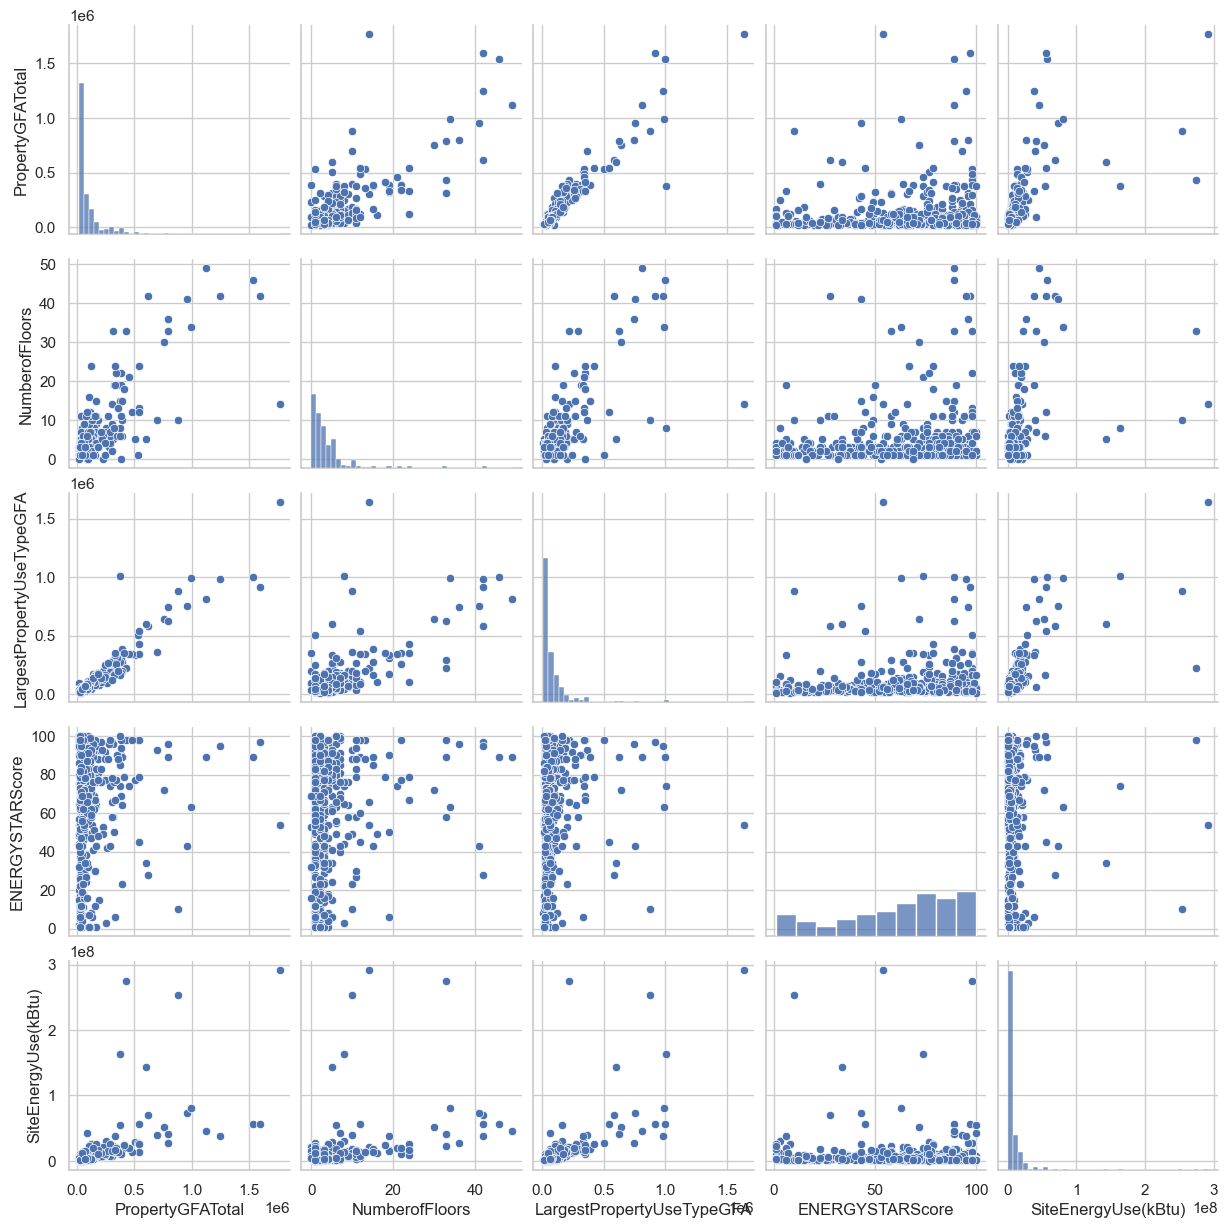

In [25]:
pairplot_cols = [
    "PropertyGFATotal",
    "NumberofFloors",
    "LargestPropertyUseTypeGFA",
    "ENERGYSTARScore",
    "SiteEnergyUse(kBtu)"
]

pairplot_cols = [col for col in pairplot_cols if col in df.columns]

pairplot_df = df[pairplot_cols].dropna().copy()

if len(pairplot_df) > 400:
    pairplot_df = pairplot_df.sample(400, random_state=42)

sns.pairplot(pairplot_df)
plt.show()

### 7. Boxplots pour repérer les valeurs extrêmes sur certaines variables clés

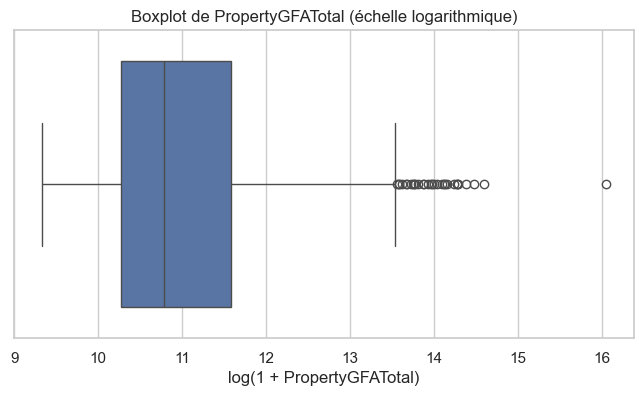

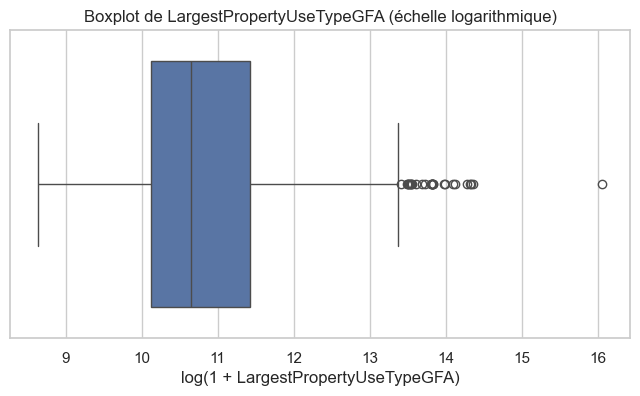

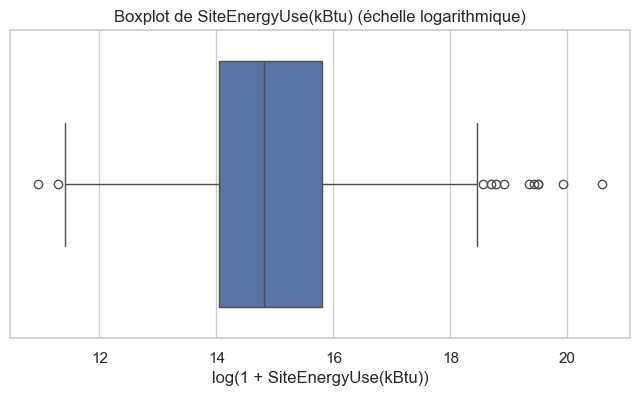

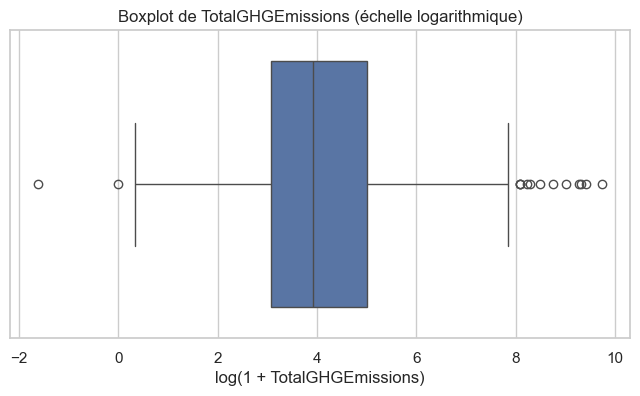

In [26]:
boxplot_cols = [
    "PropertyGFATotal",
    "LargestPropertyUseTypeGFA",
    "SiteEnergyUse(kBtu)",
    "TotalGHGEmissions"
]

boxplot_cols = [col for col in boxplot_cols if col in df.columns]

for col in boxplot_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=np.log1p(df[col].dropna()))
    plt.title(f"Boxplot de {col} (échelle logarithmique)")
    plt.xlabel(f"log(1 + {col})")
    plt.show()

### 8. Répartition par quartier

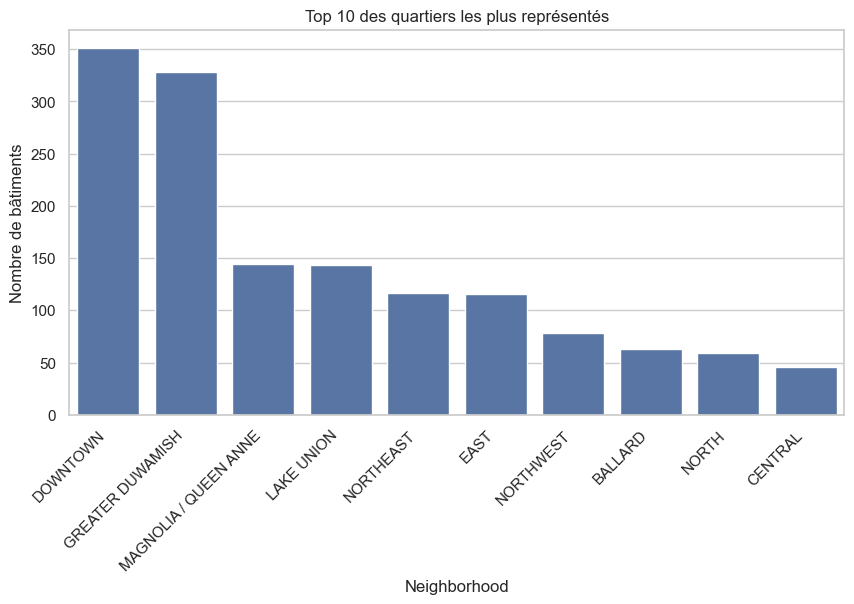

In [27]:
top_neighborhoods = df["Neighborhood"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_neighborhoods.index, y=top_neighborhoods.values)
plt.title("Top 10 des quartiers les plus représentés")
plt.xlabel("Neighborhood")
plt.ylabel("Nombre de bâtiments")
plt.xticks(rotation=45, ha="right")
plt.show()

### 9. Interprétation des résultats

L’analyse exploratoire met en évidence plusieurs enseignements importants.

Premièrement, la **surface totale du bâtiment** apparaît comme un facteur fortement lié à la consommation énergétique. Le nuage de points en échelle logarithmique montre une relation positive nette entre `PropertyGFATotal` et `SiteEnergyUse(kBtu)` : les bâtiments les plus grands consomment globalement davantage.

Deuxièmement, le **type principal du bâtiment** influence également la consommation. Les boxplots indiquent que certaines catégories, comme les **Large Office** ou les **Hotels**, présentent des niveaux de consommation plus élevés que des catégories comme les **Warehouses** ou les **Worship Facilities**.

Troisièmement, la distinction entre bâtiments **mono-usage** et **multi-usages** est pertinente. Les bâtiments multi-usages présentent une consommation médiane légèrement plus élevée et une dispersion plus importante, ce qui suggère une structure fonctionnelle plus complexe.

Enfin, la matrice de corrélation montre que les variables de **surface** (`PropertyGFATotal`, `PropertyGFABuilding(s)`, `LargestPropertyUseTypeGFA`) sont fortement corrélées à la cible, mais également fortement corrélées entre elles. Cela devra être pris en compte dans la préparation des variables pour la modélisation afin d’éviter une trop forte redondance.

### 10. Conclusion de l’analyse exploratoire

Cette première analyse exploratoire a permis de :
- restreindre le périmètre aux bâtiments non résidentiels pertinents ;
- supprimer les colonnes trop incomplètes ou non exploitables ;
- identifier la cible principale `SiteEnergyUse(kBtu)` ;
- mettre en évidence l’importance de la **surface**, du **type de bâtiment** et de la **complexité d’usage** dans l’explication de la consommation énergétique ;
- repérer une forte asymétrie de la cible et une redondance importante entre plusieurs variables de surface.

Ces constats fournissent une base solide pour la suite du projet, en particulier pour la phase de **feature engineering** et de **préparation des variables avant modélisation**.

### 11. Visualisations complémentaires pour mieux démontrer les résultats

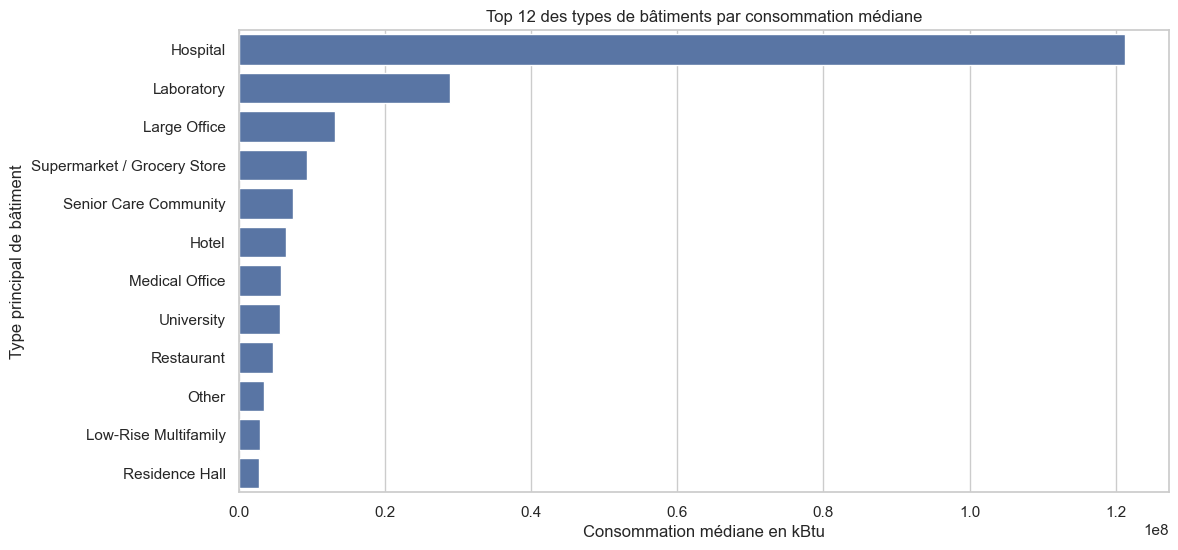

In [28]:
# 1) Consommation médiane par type principal de bâtiment
median_by_type = (
    df.groupby("PrimaryPropertyType")[target]
    .median()
    .sort_values(ascending=False)
    .head(12)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=median_by_type.values, y=median_by_type.index)
plt.title("Top 12 des types de bâtiments par consommation médiane")
plt.xlabel("Consommation médiane en kBtu")
plt.ylabel("Type principal de bâtiment")
plt.show()

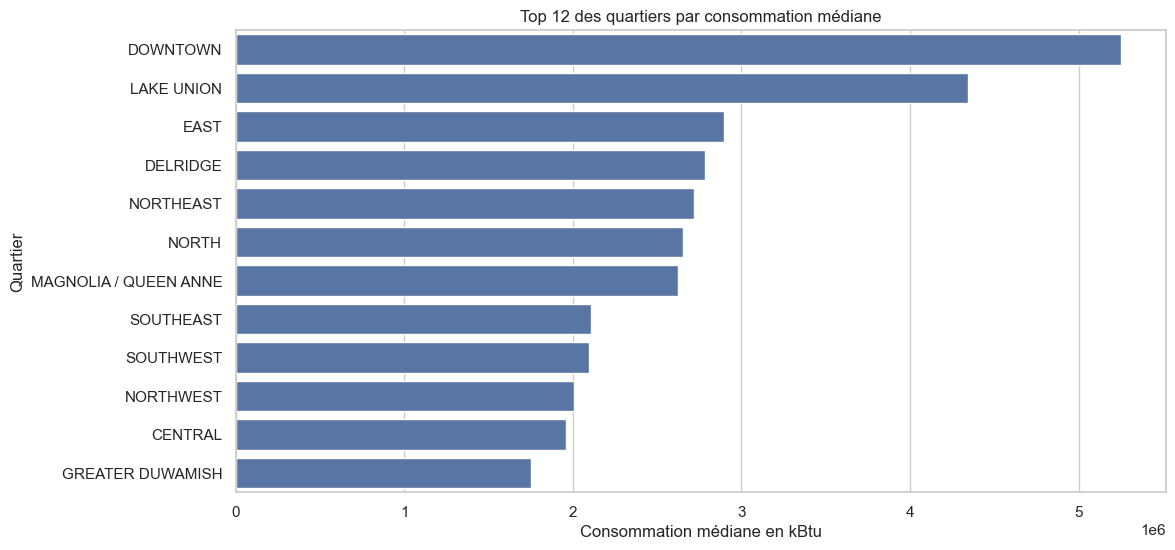

In [29]:
# 2) Consommation médiane par quartier
median_by_neighborhood = (
    df.groupby("Neighborhood")[target]
    .median()
    .sort_values(ascending=False)
    .head(12)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=median_by_neighborhood.values, y=median_by_neighborhood.index)
plt.title("Top 12 des quartiers par consommation médiane")
plt.xlabel("Consommation médiane en kBtu")
plt.ylabel("Quartier")
plt.show()

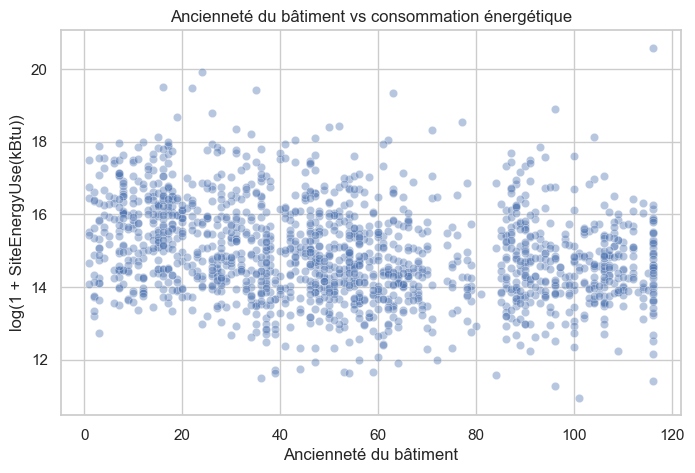

In [30]:
# 3) Ancienneté du bâtiment vs consommation
building_age_plot = 2016 - df["YearBuilt"]

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=building_age_plot,
    y=np.log1p(df[target]),
    alpha=0.4
)
plt.title("Ancienneté du bâtiment vs consommation énergétique")
plt.xlabel("Ancienneté du bâtiment")
plt.ylabel(f"log(1 + {target})")
plt.show()

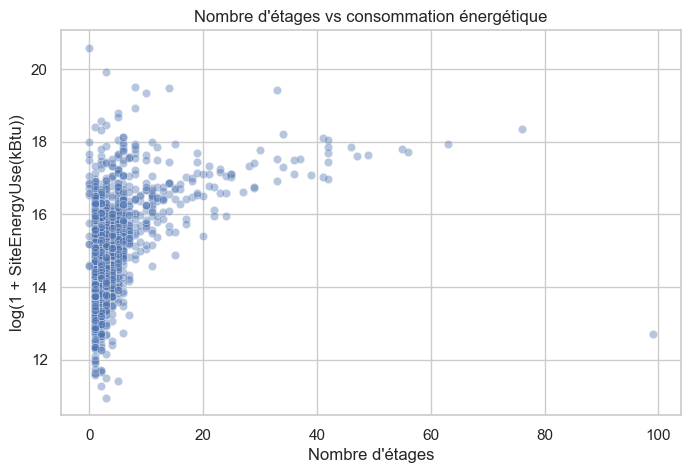

In [31]:
# 4) Nombre d'étages vs consommation
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="NumberofFloors",
    y=np.log1p(df[target]),
    alpha=0.4
)
plt.title("Nombre d'étages vs consommation énergétique")
plt.xlabel("Nombre d'étages")
plt.ylabel(f"log(1 + {target})")
plt.show()

Ces visualisations complémentaires permettent de donner un sens métier aux résultats : certains types de bâtiments, certains quartiers, ainsi que les bâtiments plus grands ou plus complexes, présentent des niveaux de consommation plus élevés. Elles rendent les conclusions plus faciles à expliquer en présentation orale.

### Feature Engineering

In [32]:
df_fe = df.copy()

# Variables temporelles
df_fe["BuildingAge"] = 2016 - df_fe["YearBuilt"]
df_fe["DecadeBuilt"] = ((df_fe["YearBuilt"] // 10) * 10).astype(str)

# Variables de structure
df_fe["HasParking"] = (df_fe["PropertyGFAParking"] > 0).astype(int)
df_fe["ParkingRatio"] = df_fe["PropertyGFAParking"] / df_fe["PropertyGFATotal"]
df_fe["BuildingAreaRatio"] = df_fe["PropertyGFABuilding(s)"] / df_fe["PropertyGFATotal"]
df_fe["AvgFloorArea"] = df_fe["PropertyGFABuilding(s)"] / df_fe["NumberofFloors"].replace(0, np.nan)
df_fe["LogPropertyGFATotal"] = np.log1p(df_fe["PropertyGFATotal"])

# Variables liées aux usages
df_fe["IsMultiUse"] = (df_fe["UsageType"] == "Multi-usages").astype(int)
df_fe["NumberOfUses"] = df_fe["ListOfAllPropertyUseTypes"].fillna("").apply(
    lambda x: len([u for u in x.split(",") if u.strip() != ""])
)
df_fe["LargestUseShare"] = df_fe["LargestPropertyUseTypeGFA"] / df_fe["PropertyGFATotal"]
df_fe["HasSecondUse"] = df_fe["SecondLargestPropertyUseType"].notna().astype(int)

# Compression de cardinalité
top_neighborhoods = df_fe["Neighborhood"].value_counts().head(10).index
df_fe["NeighborhoodGroup"] = df_fe["Neighborhood"].apply(
    lambda x: x if x in top_neighborhoods else "OTHER"
)

top_property_types = df_fe["PrimaryPropertyType"].value_counts().head(10).index
df_fe["PrimaryPropertyTypeGroup"] = df_fe["PrimaryPropertyType"].apply(
    lambda x: x if x in top_property_types else "OTHER"
)

# Présence de sources d'énergie
df_fe["HasSteam"] = (df_fe["SteamUse(kBtu)"] > 0).astype(int)
df_fe["HasNaturalGas"] = (df_fe["NaturalGas(kBtu)"] > 0).astype(int)
df_fe["HasElectricity"] = (df_fe["Electricity(kBtu)"] > 0).astype(int)

# Nettoyage des divisions problématiques
engineered_numeric_cols = [
    "ParkingRatio",
    "BuildingAreaRatio",
    "AvgFloorArea",
    "LargestUseShare"
]

for col in engineered_numeric_cols:
    df_fe[col] = df_fe[col].replace([np.inf, -np.inf], np.nan)

print(df_fe.shape)
df_fe.head()

(1548, 59)


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity,UsageType,BuildingAge,DecadeBuilt,HasParking,ParkingRatio,BuildingAreaRatio,AvgFloorArea,LogPropertyGFATotal,IsMultiUse,NumberOfUses,LargestUseShare,HasSecondUse,NeighborhoodGroup,PrimaryPropertyTypeGroup,HasSteam,HasNaturalGas,HasElectricity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,Compliant,NaN,249.98,2.83,Mono-usage,89,1920,0,0.000000,1.000000,7369.500000,11.390023,0,1,1.000000,0,DOWNTOWN,Hotel,1,1,1
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,Compliant,NaN,295.86,2.86,Multi-usages,20,1990,1,0.145453,0.854547,8045.636364,11.547974,1,3,0.809918,1,DOWNTOWN,Hotel,0,1,1
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,Compliant,NaN,2089.28,2.19,Mono-usage,47,1960,1,0.205748,0.794252,18521.756098,13.770629,0,1,0.791220,0,DOWNTOWN,Hotel,1,1,1
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,Compliant,NaN,286.43,4.67,Mono-usage,90,1920,0,0.000000,1.000000,6132.000000,11.023878,0,1,1.000000,0,DOWNTOWN,Hotel,1,1,1
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,Compliant,NaN,505.01,2.88,Multi-usages,36,1980,1,0.353115,0.646885,6310.000000,12.075856,1,3,0.703070,1,DOWNTOWN,Hotel,0,1,1


Le feature engineering a permis d’enrichir le jeu de données avec des variables issues de plusieurs dimensions : temporalité (`BuildingAge`, `DecadeBuilt`), structure (`HasParking`, `ParkingRatio`, `BuildingAreaRatio`, `AvgFloorArea`, `LogPropertyGFATotal`), usage (`IsMultiUse`, `NumberOfUses`, `LargestUseShare`, `HasSecondUse`) et localisation (`NeighborhoodGroup`, `PrimaryPropertyTypeGroup`). Des indicateurs binaires sur la présence des sources d’énergie (`HasSteam`, `HasNaturalGas`, `HasElectricity`) ont également été créés sans utiliser directement les niveaux de consommation, afin d’éviter le data leakage.

In [33]:
print(df_fe.shape)
print(df_fe.columns.tolist())

(1548, 59)
['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType', 'PropertyName', 'Address', 'City', 'State', 'ZipCode', 'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)', 'DefaultData', 'ComplianceStatus', 'Outlier', 'TotalGHGEmissions', 'GHGEmissionsIntensity', 'UsageType', 'BuildingAge', 'DecadeBuilt', 'HasParking', 'ParkingRatio', 'BuildingAreaRatio', 'AvgFloorArea', 'LogPropertyGFATotal', 'IsMultiUse', 'N

In [34]:
print(df_fe.shape)

new_features = [
    "BuildingAge",
    "DecadeBuilt",
    "HasParking",
    "ParkingRatio",
    "BuildingAreaRatio",
    "AvgFloorArea",
    "LogPropertyGFATotal",
    "IsMultiUse",
    "NumberOfUses",
    "LargestUseShare",
    "HasSecondUse",
    "NeighborhoodGroup",
    "PrimaryPropertyTypeGroup",
    "HasSteam",
    "HasNaturalGas",
    "HasElectricity"
]

for col in new_features:
    print(col, "->", col in df_fe.columns)

(1548, 59)
BuildingAge -> True
DecadeBuilt -> True
HasParking -> True
ParkingRatio -> True
BuildingAreaRatio -> True
AvgFloorArea -> True
LogPropertyGFATotal -> True
IsMultiUse -> True
NumberOfUses -> True
LargestUseShare -> True
HasSecondUse -> True
NeighborhoodGroup -> True
PrimaryPropertyTypeGroup -> True
HasSteam -> True
HasNaturalGas -> True
HasElectricity -> True


La vérification finale confirme que toutes les variables créées lors du feature engineering sont bien présentes dans le DataFrame enrichi df_fe. Le jeu de données est donc prêt pour la phase de modélisation.


# Modélisation

### Import des modules 

In [35]:
# Sélection / validation
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_validate,
    KFold,
)

# Métriques
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Interprétation
from sklearn.inspection import permutation_importance

# Préprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

In [36]:
target = "SiteEnergyUse(kBtu)"

### Sélection des variables pour la modélisation

In [37]:

# Création du DataFrame de modélisation
df_model = df_fe.copy()

print("df_model créé :", df_model.shape)

df_model créé : (1548, 59)


In [38]:
# Colonnes à exclure pour éviter le data leakage ou parce qu'elles sont peu pertinentes
leakage_or_useless_cols = [
    "OSEBuildingID",
    "DataYear",
    "PropertyName",
    "Address",
    "City",
    "State",
    "ZipCode",
    "TaxParcelIdentificationNumber",
    "Comments",
    "ComplianceStatus",
    "Outlier",
    "DefaultData",
    "SiteEnergyUse(kBtu)",
    "SiteEnergyUseWN(kBtu)",
    "SiteEUI(kBtu/sf)",
    "SiteEUIWN(kBtu/sf)",
    "SourceEUI(kBtu/sf)",
    "SourceEUIWN(kBtu/sf)",
    "SteamUse(kBtu)",
    "Electricity(kWh)",
    "Electricity(kBtu)",
    "NaturalGas(therms)",
    "NaturalGas(kBtu)",
    "TotalGHGEmissions",
    "GHGEmissionsIntensity",
    "ENERGYSTARScore"
]

leakage_or_useless_cols = [col for col in leakage_or_useless_cols if col in df_model.columns]

print("Nombre de colonnes exclues :", len(leakage_or_useless_cols))
print(leakage_or_useless_cols)

Nombre de colonnes exclues : 25
['OSEBuildingID', 'DataYear', 'PropertyName', 'Address', 'City', 'State', 'ZipCode', 'TaxParcelIdentificationNumber', 'ComplianceStatus', 'Outlier', 'DefaultData', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SteamUse(kBtu)', 'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)', 'TotalGHGEmissions', 'GHGEmissionsIntensity', 'ENERGYSTARScore']


In [39]:
feature_cols = [col for col in df_model.columns if col not in leakage_or_useless_cols]

print("Nombre de variables conservées :", len(feature_cols))
print(feature_cols)

Nombre de variables conservées : 34
['BuildingType', 'PrimaryPropertyType', 'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA', 'UsageType', 'BuildingAge', 'DecadeBuilt', 'HasParking', 'ParkingRatio', 'BuildingAreaRatio', 'AvgFloorArea', 'LogPropertyGFATotal', 'IsMultiUse', 'NumberOfUses', 'LargestUseShare', 'HasSecondUse', 'NeighborhoodGroup', 'PrimaryPropertyTypeGroup', 'HasSteam', 'HasNaturalGas', 'HasElectricity']


In [40]:
numeric_features = [
    "CouncilDistrictCode",
    "Latitude",
    "Longitude",
    "BuildingAge",
    "NumberofBuildings",
    "NumberofFloors",
    "LogPropertyGFATotal",
    "PropertyGFAParking",
    "PropertyGFABuilding(s)",
    "LargestPropertyUseTypeGFA",
    "ParkingRatio",
    "BuildingAreaRatio",
    "AvgFloorArea",
    "NumberOfUses",
    "LargestUseShare",
    "HasParking",
    "HasSecondUse",
    "HasSteam",
    "HasNaturalGas",
    "HasElectricity"
]

categorical_features = [
    "BuildingType",
    "PrimaryPropertyTypeGroup",
    "NeighborhoodGroup",
    "LargestPropertyUseType",
    "UsageType",
    "DecadeBuilt"
]

In [41]:
X = df_model[numeric_features + categorical_features].copy()
y = np.log1p(df_model[target])

print("Shape de X :", X.shape)
print("Shape de y :", y.shape)
X.head()

Shape de X : (1548, 26)
Shape de y : (1548,)


,CouncilDistrictCode,Latitude,Longitude,BuildingAge,NumberofBuildings,NumberofFloors,LogPropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ParkingRatio,BuildingAreaRatio,AvgFloorArea,NumberOfUses,LargestUseShare,HasParking,HasSecondUse,HasSteam,HasNaturalGas,HasElectricity,BuildingType,PrimaryPropertyTypeGroup,NeighborhoodGroup,LargestPropertyUseType,UsageType,DecadeBuilt
0,7,47.61220,-122.33799,89,1.0,12,11.390023,0,88434,88434.0,0.000000,1.000000,7369.500000,1,1.000000,0,0,1,1,1,NonResidential,Hotel,DOWNTOWN,Hotel,Mono-usage,1920
1,7,47.61317,-122.33393,20,1.0,11,11.547974,15064,88502,83880.0,0.145453,0.854547,8045.636364,3,0.809918,1,1,0,1,1,NonResidential,Hotel,DOWNTOWN,Hotel,Multi-usages,1990
2,7,47.61393,-122.33810,47,1.0,41,13.770629,196718,759392,756493.0,0.205748,0.794252,18521.756098,1,0.791220,1,0,1,1,1,NonResidential,Hotel,DOWNTOWN,Hotel,Mono-usage,1960
3,7,47.61412,-122.33664,90,1.0,10,11.023878,0,61320,61320.0,0.000000,1.000000,6132.000000,1,1.000000,0,0,1,1,1,NonResidential,Hotel,DOWNTOWN,Hotel,Mono-usage,1920
4,7,47.61375,-122.34047,36,1.0,18,12.075856,62000,113580,123445.0,0.353115,0.646885,6310.000000,3,0.703070,1,1,0,1,1,NonResidential,Hotel,DOWNTOWN,Hotel,Multi-usages,1980


In [42]:
for col in numeric_features + categorical_features:
    if col not in df_model.columns:
        print("Colonne manquante :", col)

### Préprocessing

In [43]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=10))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### Séparation du jeu de données

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (1238, 26)
X_test  : (310, 26)
y_train : (1238,)
y_test  : (310,)


### Modèle baseline

In [45]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="mean"))
    ]
)

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [46]:
y_train_pred_baseline = np.expm1(baseline_model.predict(X_train))
y_test_pred_baseline = np.expm1(baseline_model.predict(X_test))

y_train_true = np.expm1(y_train)
y_test_true = np.expm1(y_test)

In [47]:
baseline_results = pd.DataFrame({
    "metric": ["RMSE", "MAE", "R2"],
    "train": [
        np.sqrt(mean_squared_error(y_train_true, y_train_pred_baseline)),
        mean_absolute_error(y_train_true, y_train_pred_baseline),
        r2_score(y_train_true, y_train_pred_baseline)
    ],
    "test": [
        np.sqrt(mean_squared_error(y_test_true, y_test_pred_baseline)),
        mean_absolute_error(y_test_true, y_test_pred_baseline),
        r2_score(y_test_true, y_test_pred_baseline)
    ]
})

baseline_results

,metric,train,test
0,RMSE,2.024747e+07,5.844768e+07
1,MAE,6.658728e+06,1.120100e+07
2,R2,-6.022687e-02,-2.552736e-02


Le modèle baseline sert de point de comparaison minimal. Ici, le `DummyRegressor` prédit une valeur moyenne sur l’ensemble d’entraînement. Il ne cherche pas à apprendre les relations entre les variables explicatives et la cible. Tous les modèles supervisés testés ensuite devront obtenir de meilleures performances que ce baseline pour être considérés comme utiles.

### Comparaison de différents modèles supervisés

Les modèles sont comparés avec les mêmes jeux de train et de test, les mêmes variables explicatives et les mêmes métriques. Une validation croisée à 5 plis est utilisée sur le jeu d'entraînement afin d'obtenir une évaluation plus robuste des performances.

In [48]:
models = {
    "LinearRegression": LinearRegression(),
    "SVR": SVR(),
    "RandomForestRegressor": RandomForestRegressor(random_state=42)
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

In [49]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test, preprocessor, cv, scoring):
    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    cv_scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    pipe.fit(X_train, y_train)

    y_train_pred = np.expm1(pipe.predict(X_train))
    y_test_pred = np.expm1(pipe.predict(X_test))

    y_train_true = np.expm1(y_train)
    y_test_true = np.expm1(y_test)

    results = {
        "model": model_name,
        "cv_train_mae": -cv_scores["train_mae"].mean(),
        "cv_test_mae": -cv_scores["test_mae"].mean(),
        "cv_train_r2": cv_scores["train_r2"].mean(),
        "cv_test_r2": cv_scores["test_r2"].mean(),
        "holdout_train_rmse": np.sqrt(mean_squared_error(y_train_true, y_train_pred)),
        "holdout_test_rmse": np.sqrt(mean_squared_error(y_test_true, y_test_pred)),
        "holdout_train_mae": mean_absolute_error(y_train_true, y_train_pred),
        "holdout_test_mae": mean_absolute_error(y_test_true, y_test_pred),
        "holdout_train_r2": r2_score(y_train_true, y_train_pred),
        "holdout_test_r2": r2_score(y_test_true, y_test_pred),
    }

    return results, pipe

In [50]:
results = []
fitted_models = {}

for model_name, model in models.items():
    model_results, fitted_pipe = evaluate_model(
        model_name=model_name,
        model=model,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        preprocessor=preprocessor,
        cv=cv,
        scoring=scoring
    )
    results.append(model_results)
    fitted_models[model_name] = fitted_pipe

results_df = pd.DataFrame(results).sort_values("holdout_test_rmse")
results_df

,model,cv_train_mae,cv_test_mae,cv_train_r2,cv_test_r2,holdout_train_rmse,holdout_test_rmse,holdout_train_mae,holdout_test_mae,holdout_train_r2,holdout_test_r2
2,RandomForestRegressor,0.197395,0.518988,0.955841,0.696476,7.248536e+06,4.727577e+07,1.668300e+06,7.471887e+06,0.864119,0.329050
1,SVR,0.379691,0.524875,0.802172,0.688348,1.369570e+07,5.636597e+07,2.820029e+06,8.633911e+06,0.514906,0.046223
0,LinearRegression,0.479785,0.508614,0.744324,0.712276,1.187587e+07,2.461623e+08,3.473686e+06,1.926723e+07,0.635256,-17.190969


In [51]:
results_plot_df = results_df[["model", "holdout_test_rmse", "holdout_test_mae", "holdout_test_r2"]].copy()
results_plot_df

,model,holdout_test_rmse,holdout_test_mae,holdout_test_r2
2,RandomForestRegressor,4.727577e+07,7.471887e+06,0.329050
1,SVR,5.636597e+07,8.633911e+06,0.046223
0,LinearRegression,2.461623e+08,1.926723e+07,-17.190969


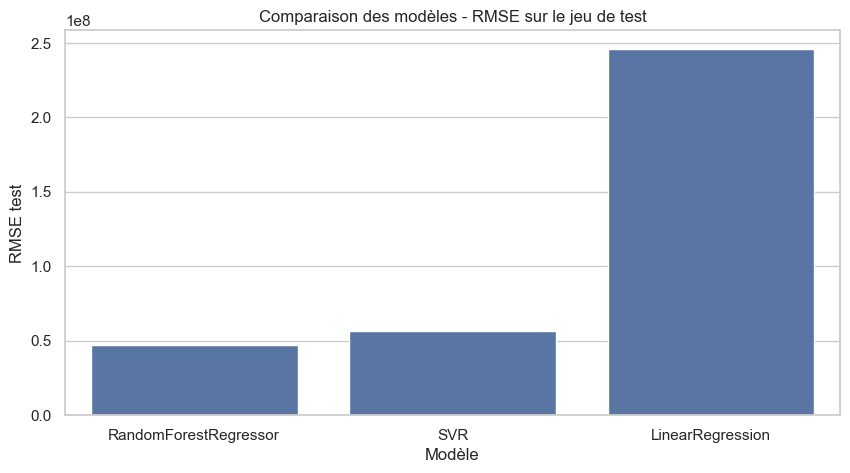

In [52]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_plot_df, x="model", y="holdout_test_rmse")
plt.title("Comparaison des modèles - RMSE sur le jeu de test")
plt.xlabel("Modèle")
plt.ylabel("RMSE test")
plt.show()

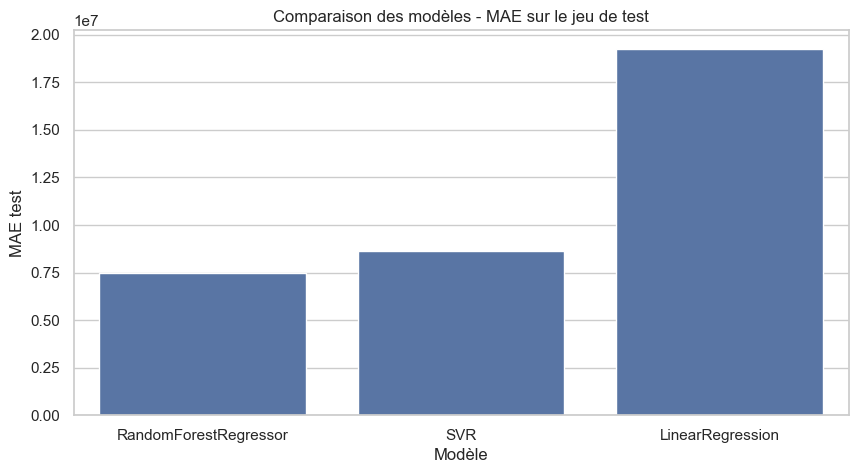

In [53]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_plot_df, x="model", y="holdout_test_mae")
plt.title("Comparaison des modèles - MAE sur le jeu de test")
plt.xlabel("Modèle")
plt.ylabel("MAE test")
plt.show()

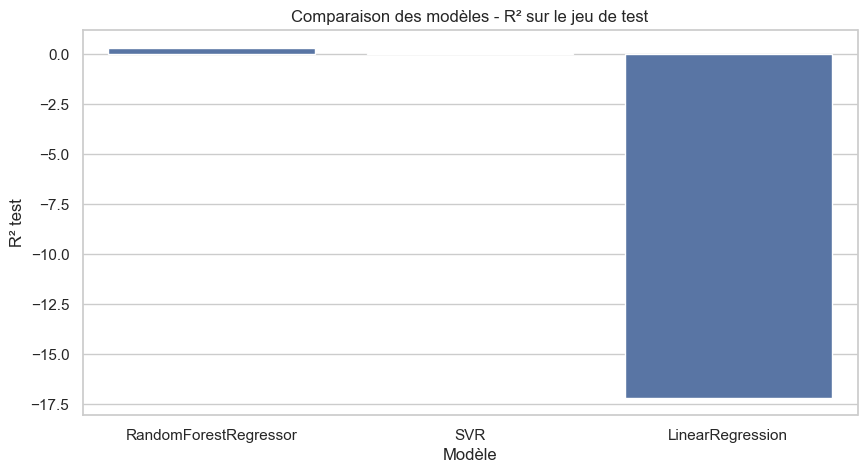

In [54]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_plot_df, x="model", y="holdout_test_r2")
plt.title("Comparaison des modèles - R² sur le jeu de test")
plt.xlabel("Modèle")
plt.ylabel("R² test")
plt.show()

Ces trois graphiques permettent de montrer rapidement pourquoi le modèle retenu est le plus pertinent : un bon modèle doit minimiser les erreurs (RMSE et MAE) tout en maximisant la part de variance expliquée (R²).

La comparaison est réalisée sur trois modèles complémentaires : une régression linéaire, un modèle non linéaire de type SVR et un modèle d'ensemble à base d'arbres avec la Random Forest. Les performances sont analysées via la validation croisée ainsi que sur le jeu de test, à l'aide des métriques RMSE, MAE et R².

In [55]:
best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]

print("Meilleur modèle selon le RMSE test :", best_model_name)

Meilleur modèle selon le RMSE test : RandomForestRegressor


### Optimisation et interprétation du modèle

In [56]:
small_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10],
    "model__min_samples_split": [2, 5]
}

In [57]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42))
    ]
)

small_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=small_param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

small_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation ti

In [58]:
print("Meilleurs paramètres (petite grille) :", small_grid_search.best_params_)
print("Meilleur score CV (MAE négative) :", small_grid_search.best_score_)

Meilleurs paramètres (petite grille) : {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Meilleur score CV (MAE négative) : -0.5178661518603285


In [59]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

In [60]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: 

In [61]:
print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur score CV (MAE négative) :", grid_search.best_score_)

Meilleurs paramètres : {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Meilleur score CV (MAE négative) : -0.5160981036189005


In [62]:
best_rf_model = grid_search.best_estimator_

y_train_pred_best = np.expm1(best_rf_model.predict(X_train))
y_test_pred_best = np.expm1(best_rf_model.predict(X_test))

y_train_true = np.expm1(y_train)
y_test_true = np.expm1(y_test)

In [63]:
best_rf_results = pd.DataFrame({
    "metric": ["RMSE", "MAE", "R2"],
    "train": [
        np.sqrt(mean_squared_error(y_train_true, y_train_pred_best)),
        mean_absolute_error(y_train_true, y_train_pred_best),
        r2_score(y_train_true, y_train_pred_best)
    ],
    "test": [
        np.sqrt(mean_squared_error(y_test_true, y_test_pred_best)),
        mean_absolute_error(y_test_true, y_test_pred_best),
        r2_score(y_test_true, y_test_pred_best)
    ]
})

best_rf_results

,metric,train,test
0,RMSE,8.894441e+06,4.723394e+07
1,MAE,1.929170e+06,7.367322e+06
2,R2,7.954051e-01,3.302371e-01


In [64]:
feature_names = best_rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = best_rf_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
6,num__LogPropertyGFATotal,0.558226
8,num__PropertyGFABuilding(s),0.071740
9,num__LargestPropertyUseTypeGFA,0.053461
2,num__Longitude,0.030953
52,cat__LargestPropertyUseType_Supermarket/Grocer...,0.028229
1,num__Latitude,0.025379
32,cat__PrimaryPropertyTypeGroup_Warehouse,0.025164
12,num__AvgFloorArea,0.025068
3,num__BuildingAge,0.024156
48,cat__LargestPropertyUseType_Non-Refrigerated W...,0.022001


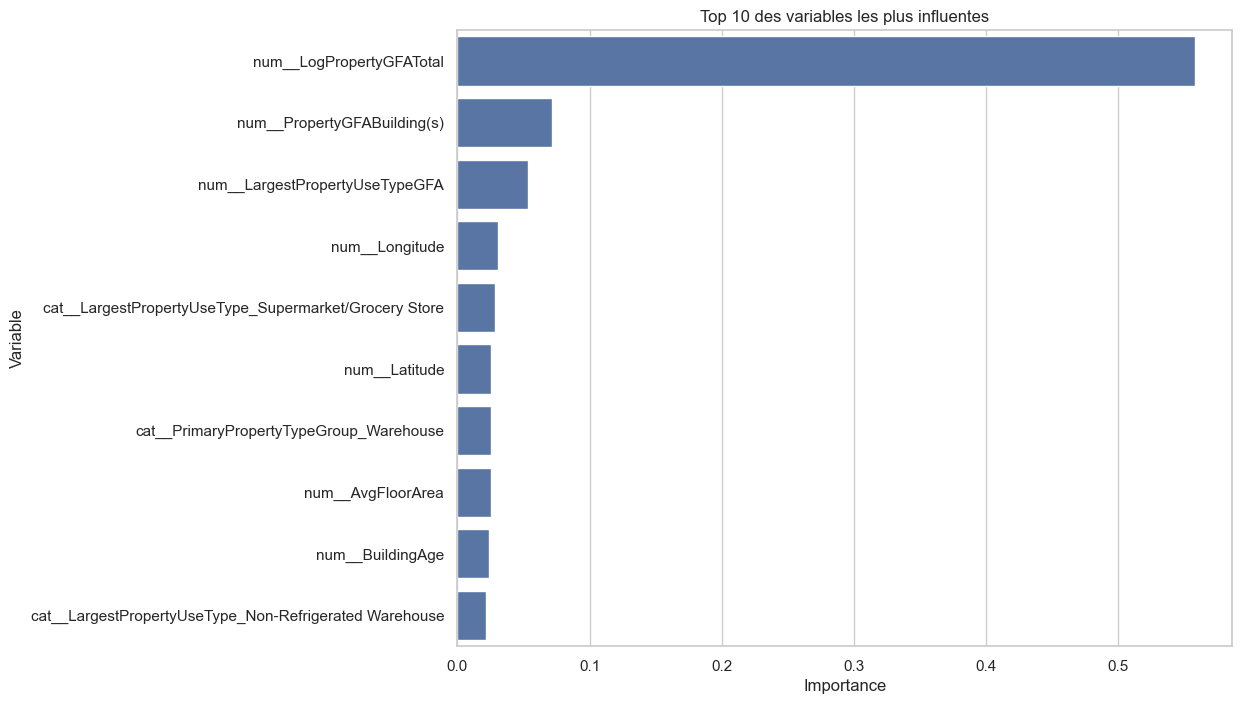

In [65]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(10),
    x="importance",
    y="feature"
)
plt.title("Top 10 des variables les plus influentes")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.show()

Ce graphique permet de montrer concrètement quels facteurs influencent le plus les prédictions du modèle : la taille du bâtiment, certains usages, ainsi que plusieurs variables structurelles et spatiales occupent généralement une place centrale.

L’optimisation du modèle a été réalisée à l’aide d’une `GridSearchCV` appliquée au `RandomForestRegressor`, qui s’était révélé le plus performant lors de l’étape précédente. Une petite grille a d’abord été testée pour valider le bon fonctionnement du pipeline, puis une grille plus complète a été utilisée pour rechercher une meilleure combinaison d’hyperparamètres.

L’évaluation finale du modèle optimisé a été effectuée sur les jeux d’entraînement et de test à l’aide des métriques RMSE, MAE et R². L’interprétation du modèle repose ensuite sur les `feature_importances_`, qui permettent d’identifier les variables ayant le plus contribué aux prédictions. Les résultats montrent quels facteurs structurels, géographiques ou fonctionnels influencent le plus la consommation énergétique des bâtiments.


## Extension : utilisation du fichier historique pour optimiser les prédictions

Cette section ajoute une approche complémentaire en exploitant le fichier historique `Building_Energy_Benchmarking_Data,_2015-Present_20260330.csv`. L'objectif est d'augmenter le volume de données disponibles, tout en conservant une démarche cohérente : harmonisation des colonnes, déduplication, feature engineering sur les colonnes communes et évaluation avec une séparation temporelle.

In [66]:
path_hist_20260330 = "../data/raw/Building_Energy_Benchmarking_Data,_2015-Present_20260330.csv"

df_hist = pd.read_csv(path_hist_20260330, low_memory=False)

print("building_consumption (2016) :", building_consumption.shape)
print("df_hist :", df_hist.shape)

building_consumption (2016) : (3376, 46)
df_hist : (34699, 46)


### Harmonisation entre le fichier 2016 détaillé et le fichier historique

In [67]:
rename_2016 = {
    "PrimaryPropertyType": "EPAPropertyType",
    "PropertyGFABuilding(s)": "PropertyGFABuildings",
    "PropertyName": "BuildingName"
}

df_2016_hist = building_consumption.rename(columns=rename_2016).copy()

common_hist_cols = sorted(set(df_2016_hist.columns) & set(df_hist.columns))

print("Nombre de colonnes communes après harmonisation :", len(common_hist_cols))
print(common_hist_cols)

Nombre de colonnes communes après harmonisation : 41
['Address', 'BuildingName', 'BuildingType', 'City', 'ComplianceStatus', 'CouncilDistrictCode', 'DataYear', 'ENERGYSTARScore', 'EPAPropertyType', 'Electricity(kBtu)', 'Electricity(kWh)', 'GHGEmissionsIntensity', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'Latitude', 'Longitude', 'NaturalGas(kBtu)', 'NaturalGas(therms)', 'Neighborhood', 'NumberofBuildings', 'NumberofFloors', 'OSEBuildingID', 'PropertyGFABuildings', 'PropertyGFAParking', 'PropertyGFATotal', 'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'State', 'SteamUse(kBtu)', 'TaxParcelIdentificationNumber', 'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA', 'TotalGHGEmissions', 'YearBuilt', 'ZipCode']


In [68]:
df_2016_hist = df_2016_hist[common_hist_cols].copy()
df_hist_common = df_hist[common_hist_cols].copy()

df_2016_hist["source_file"] = "2016_detail"
df_hist_common["source_file"] = "2015_present"

df_all_hist = pd.concat([df_2016_hist, df_hist_common], axis=0, ignore_index=True)

df_all_hist["source_priority"] = df_all_hist["source_file"].map({
    "2016_detail": 0,
    "2015_present": 1
})

df_all_hist = df_all_hist.sort_values(["OSEBuildingID", "DataYear", "source_priority"])
df_all_hist = df_all_hist.drop_duplicates(subset=["OSEBuildingID", "DataYear"], keep="first").copy()

print("Shape après concaténation et déduplication :", df_all_hist.shape)
print(df_all_hist["DataYear"].value_counts().sort_index())

Shape après concaténation et déduplication : (34881, 43)
DataYear
2015    3175
2016    3435
2017    3310
2018    3381
2019    3456
2020    3530
2021    3578
2022    3617
2023    3687
2024    3712
Name: count, dtype: int64


### Filtrage métier sur le dataset historique

In [69]:
building_types_to_keep_hist = [
    "NonResidential",
    "Nonresidential COS",
    "Nonresidential WA",
    "Campus",
    "SPS-District K-12"
]

numeric_cols_to_fix_hist = [
    "SiteEnergyUse(kBtu)",
    "PropertyGFATotal",
    "NumberofBuildings",
    "NumberofFloors",
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseTypeGFA",
    "Latitude",
    "Longitude",
    "YearBuilt",
    "DataYear",
    "PropertyGFABuildings",
    "PropertyGFAParking",
    "SiteEnergyUseWN(kBtu)",
    "SteamUse(kBtu)",
    "Electricity(kWh)",
    "Electricity(kBtu)",
    "NaturalGas(therms)",
    "NaturalGas(kBtu)"
]

df_hist_model = df_all_hist.copy()

print("Répartition initiale par année :")
print(df_hist_model["DataYear"].value_counts(dropna=False).sort_index())

# Nettoyage robuste des chaînes avant conversion numérique
for col in numeric_cols_to_fix_hist:
    if col in df_hist_model.columns:
        df_hist_model[col] = (
            df_hist_model[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.strip()
            .replace({"": np.nan, "nan": np.nan, "None": np.nan})
        )
        df_hist_model[col] = pd.to_numeric(df_hist_model[col], errors="coerce")

# Normalisation des colonnes textuelles utilisées dans les filtres
if "BuildingType" in df_hist_model.columns:
    df_hist_model["BuildingType"] = df_hist_model["BuildingType"].astype(str).str.strip()

if "Neighborhood" in df_hist_model.columns:
    df_hist_model["Neighborhood"] = df_hist_model["Neighborhood"].astype(str).str.upper().str.strip()

# Diagnostic des libellés BuildingType les plus fréquents
print("\nTop 20 BuildingType avant filtrage :")
print(df_hist_model["BuildingType"].value_counts(dropna=False).head(20))

# Filtre plus robuste que l'égalité stricte pour conserver les variantes textuelles
building_type_upper = df_hist_model["BuildingType"].str.upper()
mask_building_type = (
    building_type_upper.str.contains("NONRESIDENTIAL", na=False)
    | building_type_upper.eq("CAMPUS")
    | building_type_upper.str.contains("SPS-DISTRICT K-12", na=False)
)

df_hist_model = df_hist_model[mask_building_type].copy()
print("\nAprès filtre BuildingType :", df_hist_model.shape)
print(df_hist_model["DataYear"].value_counts(dropna=False).sort_index())

df_hist_model = df_hist_model[df_hist_model["SiteEnergyUse(kBtu)"].notna()].copy()
print("\nAprès notna SiteEnergyUse(kBtu) :", df_hist_model.shape)
print(df_hist_model["DataYear"].value_counts(dropna=False).sort_index())

df_hist_model = df_hist_model[df_hist_model["SiteEnergyUse(kBtu)"] > 0].copy()
print("\nAprès SiteEnergyUse(kBtu) > 0 :", df_hist_model.shape)
print(df_hist_model["DataYear"].value_counts(dropna=False).sort_index())

df_hist_model = df_hist_model[df_hist_model["PropertyGFATotal"].notna()].copy()
print("\nAprès notna PropertyGFATotal :", df_hist_model.shape)
print(df_hist_model["DataYear"].value_counts(dropna=False).sort_index())

df_hist_model = df_hist_model[df_hist_model["PropertyGFATotal"] > 0].copy()
print("\nAprès PropertyGFATotal > 0 :", df_hist_model.shape)
print(df_hist_model["DataYear"].value_counts(dropna=False).sort_index())

# Création de la variable UsageType sur le périmètre conservé
if "SecondLargestPropertyUseType" in df_hist_model.columns:
    df_hist_model["UsageType"] = df_hist_model["SecondLargestPropertyUseType"].apply(
        lambda x: "Mono-usage" if pd.isna(x) else "Multi-usages"
    )

print("\nShape finale du dataset historique filtré :", df_hist_model.shape)
print(df_hist_model["DataYear"].value_counts(dropna=False).sort_index())

Répartition initiale par année :
DataYear
2015    3175
2016    3435
2017    3310
2018    3381
2019    3456
2020    3530
2021    3578
2022    3617
2023    3687
2024    3712
Name: count, dtype: int64

Top 20 BuildingType avant filtrage :
BuildingType
NonResidential          13836
Multifamily LR (1-4)    10560
Multifamily MR (5-9)     6981
Multifamily HR (10+)     1273
SPS-District K-12         948
Nonresidential COS        673
Campus                    411
Nonresidential WA         199
Name: count, dtype: int64

Après filtre BuildingType : (16067, 43)
DataYear
2015    1516
2016    1698
2017    1549
2018    1571
2019    1587
2020    1602
2021    1613
2022    1628
2023    1647
2024    1656
Name: count, dtype: int64

Après notna SiteEnergyUse(kBtu) : (15491, 43)
DataYear
2015    1493
2016    1682
2017    1531
2018    1547
2019    1571
2020    1572
2021    1464
2022    1453
2023    1565
2024    1613
Name: count, dtype: int64

Après SiteEnergyUse(kBtu) > 0 : (15475, 43)
DataYear
2015    1493


In [70]:
print(df_hist_model.shape)
print(df_hist_model.dtypes[[
    "DataYear",
    "YearBuilt",
    "NumberofFloors",
    "PropertyGFATotal",
    "PropertyGFAParking",
    "PropertyGFABuildings",
    "LargestPropertyUseTypeGFA"
]])

for col in [
    "DataYear",
    "YearBuilt",
    "NumberofFloors",
    "PropertyGFATotal",
    "PropertyGFAParking",
    "PropertyGFABuildings",
    "LargestPropertyUseTypeGFA",
    "ListOfAllPropertyUseTypes",
    "EPAPropertyType",
    "Neighborhood",
    "SecondLargestPropertyUseType"
]:
    print(col, "->", col in df_hist_model.columns)

(15475, 44)
DataYear                       int64
YearBuilt                      int64
NumberofFloors                 int64
PropertyGFATotal               int64
PropertyGFAParking             int64
PropertyGFABuildings           int64
LargestPropertyUseTypeGFA    float64
dtype: object
DataYear -> True
YearBuilt -> True
NumberofFloors -> True
PropertyGFATotal -> True
PropertyGFAParking -> True
PropertyGFABuildings -> True
LargestPropertyUseTypeGFA -> True
ListOfAllPropertyUseTypes -> False
EPAPropertyType -> True
Neighborhood -> True
SecondLargestPropertyUseType -> True


### Feature engineering sur le dataset historique

In [71]:
df_hist_fe = df_hist_model.copy()

cols_num_hist_fe = [
    "DataYear",
    "YearBuilt",
    "NumberofFloors",
    "PropertyGFATotal",
    "PropertyGFAParking",
    "PropertyGFABuildings",
    "LargestPropertyUseTypeGFA"
]

for col in cols_num_hist_fe:
    if col in df_hist_fe.columns:
        df_hist_fe[col] = pd.to_numeric(df_hist_fe[col], errors="coerce")

df_hist_fe["BuildingAge"] = df_hist_fe["DataYear"] - df_hist_fe["YearBuilt"]
df_hist_fe["DecadeBuilt"] = ((df_hist_fe["YearBuilt"] // 10) * 10).astype("Int64").astype(str)

df_hist_fe["HasParking"] = (df_hist_fe["PropertyGFAParking"] > 0).astype(int)
df_hist_fe["ParkingRatio"] = df_hist_fe["PropertyGFAParking"] / df_hist_fe["PropertyGFATotal"]
df_hist_fe["BuildingAreaRatio"] = df_hist_fe["PropertyGFABuildings"] / df_hist_fe["PropertyGFATotal"]
df_hist_fe["AvgFloorArea"] = df_hist_fe["PropertyGFABuildings"] / df_hist_fe["NumberofFloors"].replace(0, np.nan)
df_hist_fe["LogPropertyGFATotal"] = np.log1p(df_hist_fe["PropertyGFATotal"])

df_hist_fe["IsMultiUse"] = (df_hist_fe["UsageType"] == "Multi-usages").astype(int)

if "ListOfAllPropertyUseTypes" in df_hist_fe.columns:
    df_hist_fe["NumberOfUses"] = df_hist_fe["ListOfAllPropertyUseTypes"].fillna("").apply(
        lambda x: len([u for u in str(x).split(",") if u.strip() != ""])
    )
else:
    df_hist_fe["NumberOfUses"] = 1 + df_hist_fe["SecondLargestPropertyUseType"].notna().astype(int)

df_hist_fe["LargestUseShare"] = df_hist_fe["LargestPropertyUseTypeGFA"] / df_hist_fe["PropertyGFATotal"]
df_hist_fe["HasSecondUse"] = df_hist_fe["SecondLargestPropertyUseType"].notna().astype(int)

top_neighborhoods_hist = df_hist_fe["Neighborhood"].astype(str).value_counts().head(10).index
df_hist_fe["NeighborhoodGroup"] = df_hist_fe["Neighborhood"].astype(str).apply(
    lambda x: x if x in top_neighborhoods_hist else "OTHER"
)

top_property_types_hist = df_hist_fe["EPAPropertyType"].astype(str).value_counts().head(10).index
df_hist_fe["PrimaryPropertyTypeGroup"] = df_hist_fe["EPAPropertyType"].astype(str).apply(
    lambda x: x if x in top_property_types_hist else "OTHER"
)

df_hist_fe["HasSteam"] = (pd.to_numeric(df_hist_fe["SteamUse(kBtu)"], errors="coerce") > 0).astype(int)
df_hist_fe["HasNaturalGas"] = (pd.to_numeric(df_hist_fe["NaturalGas(kBtu)"], errors="coerce") > 0).astype(int)
df_hist_fe["HasElectricity"] = (pd.to_numeric(df_hist_fe["Electricity(kBtu)"], errors="coerce") > 0).astype(int)

for col in ["ParkingRatio", "BuildingAreaRatio", "AvgFloorArea", "LargestUseShare"]:
    df_hist_fe[col] = df_hist_fe[col].replace([np.inf, -np.inf], np.nan)

print(df_hist_fe.shape)
df_hist_fe.head()

(15475, 60)


,Address,BuildingName,BuildingType,City,ComplianceStatus,CouncilDistrictCode,DataYear,ENERGYSTARScore,EPAPropertyType,Electricity(kBtu),Electricity(kWh),GHGEmissionsIntensity,LargestPropertyUseType,LargestPropertyUseTypeGFA,Latitude,Longitude,NaturalGas(kBtu),NaturalGas(therms),Neighborhood,NumberofBuildings,NumberofFloors,OSEBuildingID,PropertyGFABuildings,PropertyGFAParking,PropertyGFATotal,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),State,SteamUse(kBtu),TaxParcelIdentificationNumber,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,TotalGHGEmissions,YearBuilt,ZipCode,source_file,source_priority,UsageType,BuildingAge,DecadeBuilt,HasParking,ParkingRatio,BuildingAreaRatio,AvgFloorArea,LogPropertyGFATotal,IsMultiUse,NumberOfUses,LargestUseShare,HasSecondUse,NeighborhoodGroup,PrimaryPropertyTypeGroup,HasSteam,HasNaturalGas,HasElectricity
34900,405 OLIVE WAY,MAYFLOWER PARK HOTEL,NonResidential,SEATTLE,Compliant,7,2015,65.0,Hotel,3686007.0,1080307.00,2.86,Hotel,88434.0,47.6122,-122.33799,1272388.0,12724.0000,DOWNTOWN,1.0,12,1,88434,0,88434,NaN,NaN,78.90000153,80.30000305,6981428.0,7097539.0,173.5,175.1000061,WA,2023032.0,659000030,NaN,NaN,252.7,1927,98101.0,2015_present,1,Mono-usage,88,1920,0,0.0,1.0,7369.5,11.390023,0,1,1.0,0,DOWNTOWN,Hotel,1,1,1
0,405 Olive way,Mayflower park hotel,NonResidential,Seattle,Compliant,7,2016,60.0,Hotel,3946027.0,1156514.25,2.83,Hotel,88434.0,47.6122,-122.33799,1276453.0,12764.5293,DOWNTOWN,1.0,12,1,88434,0,88434,NaN,NaN,81.699997,84.300003,7226362.5,7456910.0,182.5,189.0,WA,2003882.0,0659000030,NaN,NaN,249.98,1927,98101.0,2016_detail,0,Mono-usage,89,1920,0,0.0,1.0,7369.5,11.390023,0,1,1.0,0,DOWNTOWN,Hotel,1,1,1
28337,405 OLIVE WAY,MAYFLOWER PARK HOTEL,NonResidential,SEATTLE,Compliant,7,2017,62.0,Hotel,3950356.0,1157783.00,2.98,Hotel,88434.0,47.6122,-122.33799,1288463.0,12885.0000,DOWNTOWN,1.0,12,1,88434,0,88434,NaN,NaN,83.19999695,82.30000305,7361655.0,7274452.0,169.3000031,166.6999969,WA,2122836.0,659000030,NaN,NaN,263.2,1927,98101.0,2015_present,1,Mono-usage,90,1920,0,0.0,1.0,7369.5,11.390023,0,1,1.0,0,DOWNTOWN,Hotel,1,1,1
24956,405 OLIVE WAY,MAYFLOWER PARK HOTEL,NonResidential,SEATTLE,Compliant,7,2018,60.0,Hotel,3907951.0,1145355.00,3.02,Hotel,88434.0,47.6122,-122.33799,1410145.0,14101.0000,DOWNTOWN,1.0,12,1,88434,0,88434,NaN,NaN,83.80000305,84.40000153,7408290.0,7465990.0,168.8999939,170.1000061,WA,2090193.0,659000030,NaN,NaN,266.7,1927,98101.0,2015_present,1,Mono-usage,91,1920,0,0.0,1.0,7369.5,11.390023,0,1,1.0,0,DOWNTOWN,Hotel,1,1,1
21500,405 OLIVE WAY,MAYFLOWER PARK HOTEL,NonResidential,SEATTLE,Compliant,7,2019,62.0,Hotel,3871996.0,1134817.00,3.02,Hotel,88434.0,47.6122,-122.33799,1320784.0,13208.0000,DOWNTOWN,1.0,12,1,88434,0,88434,NaN,NaN,83.09999847,83.30000305,7351858.0,7363210.0,167.6000061,167.6000061,WA,2159078.0,659000030,NaN,NaN,267.3,1927,98101.0,2015_present,1,Mono-usage,92,1920,0,0.0,1.0,7369.5,11.390023,0,1,1.0,0,DOWNTOWN,Hotel,1,1,1


### Préparation des features et séparation temporelle

In [72]:
hist_target = "SiteEnergyUse(kBtu)"

hist_leakage_cols = [
    "OSEBuildingID",
    "BuildingName",
    "Address",
    "City",
    "State",
    "ZipCode",
    "TaxParcelIdentificationNumber",
    "ComplianceStatus",
    "Outlier",
    "DefaultData",
    "source_file",
    "source_priority",
    "SiteEnergyUse(kBtu)",
    "SiteEnergyUseWN(kBtu)",
    "SiteEUI(kBtu/sf)",
    "SiteEUIWN(kBtu/sf)",
    "SourceEUI(kBtu/sf)",
    "SourceEUIWN(kBtu/sf)",
    "SteamUse(kBtu)",
    "Electricity(kWh)",
    "Electricity(kBtu)",
    "NaturalGas(therms)",
    "NaturalGas(kBtu)",
    "TotalGHGEmissions",
    "GHGEmissionsIntensity",
    "ENERGYSTARScore"
]

hist_numeric_features = [
    "DataYear",
    "CouncilDistrictCode",
    "Latitude",
    "Longitude",
    "BuildingAge",
    "NumberofBuildings",
    "NumberofFloors",
    "LogPropertyGFATotal",
    "PropertyGFAParking",
    "PropertyGFABuildings",
    "LargestPropertyUseTypeGFA",
    "ParkingRatio",
    "BuildingAreaRatio",
    "AvgFloorArea",
    "NumberOfUses",
    "LargestUseShare",
    "HasParking",
    "HasSecondUse",
    "HasSteam",
    "HasNaturalGas",
    "HasElectricity"
]

hist_categorical_features = [
    "BuildingType",
    "PrimaryPropertyTypeGroup",
    "NeighborhoodGroup",
    "LargestPropertyUseType",
    "UsageType",
    "DecadeBuilt"
]

hist_feature_cols = [
    col for col in hist_numeric_features + hist_categorical_features
    if col in df_hist_fe.columns and col not in hist_leakage_cols
]

X_hist = df_hist_fe[hist_feature_cols].copy()
y_hist = np.log1p(df_hist_fe[hist_target])

year_counts = df_hist_fe["DataYear"].value_counts().sort_index()
unique_years = sorted(df_hist_fe["DataYear"].dropna().unique().tolist())

print("Répartition par année :")
print(year_counts)

# Priorité à une séparation temporelle si plusieurs années sont présentes.
# Si une seule année subsiste après filtrage, on bascule proprement vers
# un split aléatoire pour éviter un jeu d'entraînement vide.
if len(unique_years) >= 2:
    test_year = int(max(unique_years))
    train_mask = df_hist_fe["DataYear"] < test_year
    test_mask = df_hist_fe["DataYear"] == test_year

    X_hist_train = X_hist.loc[train_mask].copy()
    X_hist_test = X_hist.loc[test_mask].copy()
    y_hist_train = y_hist.loc[train_mask].copy()
    y_hist_test = y_hist.loc[test_mask].copy()

    split_strategy = f"temporelle (train < {test_year}, test = {test_year})"
else:
    X_hist_train, X_hist_test, y_hist_train, y_hist_test = train_test_split(
        X_hist,
        y_hist,
        test_size=0.2,
        random_state=42
    )
    test_year = int(unique_years[0]) if len(unique_years) == 1 else None
    split_strategy = "aléatoire (fallback car une seule année disponible)"

print("Stratégie de split :", split_strategy)
print("Année de référence :", test_year)
print("X_hist_train :", X_hist_train.shape)
print("X_hist_test  :", X_hist_test.shape)
print("y_hist_train :", y_hist_train.shape)
print("y_hist_test  :", y_hist_test.shape)

Répartition par année :
DataYear
2015    1493
2016    1666
2017    1531
2018    1547
2019    1571
2020    1572
2021    1464
2022    1453
2023    1565
2024    1613
Name: count, dtype: int64
Stratégie de split : temporelle (train < 2024, test = 2024)
Année de référence : 2024
X_hist_train : (13862, 27)
X_hist_test  : (1613, 27)
y_hist_train : (13862,)
y_hist_test  : (1613,)


Lorsque plusieurs années sont disponibles, la séparation temporelle est privilégiée pour éviter une évaluation trop optimiste. Si le filtrage ne laisse finalement qu'une seule année, un `train_test_split` classique est utilisé comme solution de repli afin de conserver un pipeline exécutable et comparable.

In [73]:
print("Répartition df_hist_fe par année :")
print(df_hist_fe["DataYear"].value_counts(dropna=False).sort_index())

print("\nShape X_hist :", X_hist.shape)
print("Shape y_hist :", y_hist.shape)

print("\nShape X_hist_train :", X_hist_train.shape)
print("Shape X_hist_test  :", X_hist_test.shape)
print("Shape y_hist_train :", y_hist_train.shape)
print("Shape y_hist_test  :", y_hist_test.shape)

print("\nColonnes de X_hist :")
print(X_hist.columns.tolist())

Répartition df_hist_fe par année :
DataYear
2015    1493
2016    1666
2017    1531
2018    1547
2019    1571
2020    1572
2021    1464
2022    1453
2023    1565
2024    1613
Name: count, dtype: int64

Shape X_hist : (15475, 27)
Shape y_hist : (15475,)

Shape X_hist_train : (13862, 27)
Shape X_hist_test  : (1613, 27)
Shape y_hist_train : (13862,)
Shape y_hist_test  : (1613,)

Colonnes de X_hist :
['DataYear', 'CouncilDistrictCode', 'Latitude', 'Longitude', 'BuildingAge', 'NumberofBuildings', 'NumberofFloors', 'LogPropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuildings', 'LargestPropertyUseTypeGFA', 'ParkingRatio', 'BuildingAreaRatio', 'AvgFloorArea', 'NumberOfUses', 'LargestUseShare', 'HasParking', 'HasSecondUse', 'HasSteam', 'HasNaturalGas', 'HasElectricity', 'BuildingType', 'PrimaryPropertyTypeGroup', 'NeighborhoodGroup', 'LargestPropertyUseType', 'UsageType', 'DecadeBuilt']


### Modèle optimisé avec les ressources historiques

In [81]:
hist_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

hist_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=10))
    ]
)

hist_preprocessor = ColumnTransformer(
    transformers=[
        ("num", hist_numeric_transformer, [c for c in hist_numeric_features if c in hist_feature_cols]),
        ("cat", hist_categorical_transformer, [c for c in hist_categorical_features if c in hist_feature_cols])
    ]
)

hist_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", hist_preprocessor),
        ("model", RandomForestRegressor(
            random_state=42,
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            min_samples_split=2
        ))
    ]
)

hist_rf_pipeline.fit(X_hist_train, y_hist_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [82]:
y_hist_train_pred = np.expm1(hist_rf_pipeline.predict(X_hist_train))
y_hist_test_pred = np.expm1(hist_rf_pipeline.predict(X_hist_test))

y_hist_train_true = np.expm1(y_hist_train)
y_hist_test_true = np.expm1(y_hist_test)

hist_results = pd.DataFrame({
    "metric": ["RMSE", "MAE", "R2"],
    "train": [
        np.sqrt(mean_squared_error(y_hist_train_true, y_hist_train_pred)),
        mean_absolute_error(y_hist_train_true, y_hist_train_pred),
        r2_score(y_hist_train_true, y_hist_train_pred)
    ],
    "test": [
        np.sqrt(mean_squared_error(y_hist_test_true, y_hist_test_pred)),
        mean_absolute_error(y_hist_test_true, y_hist_test_pred),
        r2_score(y_hist_test_true, y_hist_test_pred)
    ]
})

hist_results

,metric,train,test
0,RMSE,8.236188e+08,1.121286e+08
1,MAE,9.117260e+06,4.215642e+06
2,R2,1.046031e-01,6.982508e-01


Cette visualisation facilite la lecture des performances du modèle historique sur l'année de test retenue. Elle permet d'expliquer plus simplement, en soutenance, le niveau d'erreur du modèle et sa capacité à généraliser à une année plus récente.

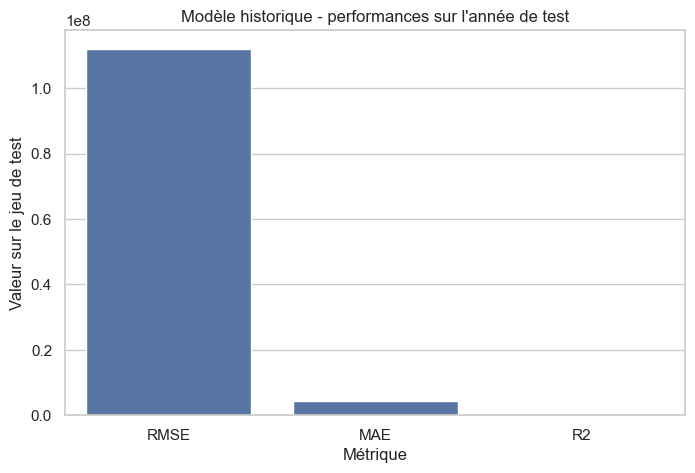

In [83]:
plt.figure(figsize=(8, 5))
sns.barplot(data=hist_results, x="metric", y="test")
plt.title("Modèle historique - performances sur l'année de test")
plt.xlabel("Métrique")
plt.ylabel("Valeur sur le jeu de test")
plt.show()

In [84]:
hist_feature_names = hist_rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
hist_importances = hist_rf_pipeline.named_steps["model"].feature_importances_

hist_importance_df = pd.DataFrame({
    "feature": hist_feature_names,
    "importance": hist_importances
}).sort_values("importance", ascending=False)

hist_importance_df.head(15)

,feature,importance
7,num__LogPropertyGFATotal,0.584287
9,num__PropertyGFABuildings,0.054617
4,num__BuildingAge,0.037579
3,num__Longitude,0.036493
13,num__AvgFloorArea,0.035956
2,num__Latitude,0.030985
10,num__LargestPropertyUseTypeGFA,0.026690
19,num__HasNaturalGas,0.025737
55,cat__LargestPropertyUseType_infrequent_sklearn,0.025404
15,num__LargestUseShare,0.015190


Cette extension utilise le fichier historique pour augmenter le volume de données et construire une évaluation plus réaliste dans le temps. Le modèle est entraîné sur toutes les années antérieures à l'année de test retenue, puis évalué sur la dernière année disponible. Cette approche permet d'utiliser davantage de signal tout en évitant un mélange aléatoire entre années proches, ce qui donnerait une estimation trop optimiste des performances.

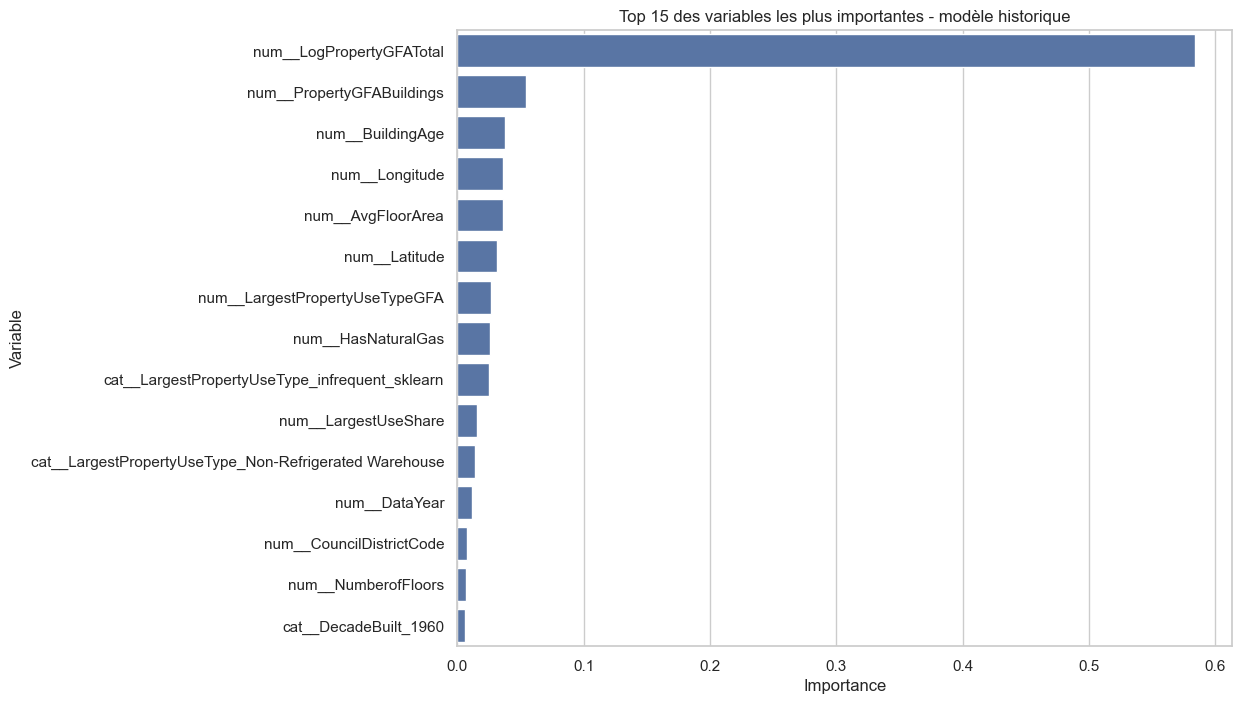

In [85]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=hist_importance_df.head(15),
    x="importance",
    y="feature"
)
plt.title("Top 15 des variables les plus importantes - modèle historique")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.show()

In [86]:
hist_rf_pipeline.fit(X_hist_train, y_hist_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [87]:
y_hist_train_pred = np.expm1(hist_rf_pipeline.predict(X_hist_train))
y_hist_test_pred = np.expm1(hist_rf_pipeline.predict(X_hist_test))

y_hist_train_true = np.expm1(y_hist_train)
y_hist_test_true = np.expm1(y_hist_test)

In [88]:
hist_results = pd.DataFrame({
    "metric": ["RMSE", "MAE", "R2"],
    "train": [
        np.sqrt(mean_squared_error(y_hist_train_true, y_hist_train_pred)),
        mean_absolute_error(y_hist_train_true, y_hist_train_pred),
        r2_score(y_hist_train_true, y_hist_train_pred)
    ],
    "test": [
        np.sqrt(mean_squared_error(y_hist_test_true, y_hist_test_pred)),
        mean_absolute_error(y_hist_test_true, y_hist_test_pred),
        r2_score(y_hist_test_true, y_hist_test_pred)
    ]
})

In [89]:
hist_feature_names = hist_rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
hist_importances = hist_rf_pipeline.named_steps["model"].feature_importances_

hist_importance_df = pd.DataFrame({
    "feature": hist_feature_names,
    "importance": hist_importances
}).sort_values("importance", ascending=False)